# 14 - Report figures

Every figure and table that appears in the final report is produced here, so there is one
place to regenerate the whole document's artefacts and one place to look at them. Output
goes to `outputs/figures/14_report_figures/`, named `figNN_MM_slug.png` after the figure
number it carries in the report.

**This notebook reads stored artefacts; it never re-runs an evaluation lane.** The lanes are
expensive and are owned by notebooks 07 and 10-13, which write `outputs/da/*/`. Anything here
that needs a number reads it from a `metrics.csv`, a `*_analysis.npz` or a `*_config.json`.
The two exceptions are cheap, deterministic recomputations that no lane stores - principal
component projections of the prior and the analog ensembles - and each says so where it
appears.

One section per report chapter. Sections for chapters not yet drafted hold the figure list
from `notes/final_report_plan.md` so it is clear what is still owed.

## Map conventions, fixed once

Maps are drawn with `pcolormesh` over **exact cell edges**, not `imshow` with an extent.
The LOVECLIM grid is cell-centred at 5.625 degree spacing, longitude -174.375 to 180.0 and
latitude -84.375 to 90.0, so an extent running centre-to-centre would place the whole field
half a cell (2.8125 degrees) out. `cell_edges` recovers the edges and `PlateCarree` puts the
mesh and the coastline in the same coordinate reference system, so alignment is exact by
construction rather than by eye.

**The coastline is modern.** During MIS3 sea level was roughly 80 m lower and ice sheets
covered North America and Fennoscandia, and LOVECLIM carries its own land-sea mask which is
not Natural Earth's. Coastlines are a geographic reference for the reader, not a statement
about palaeogeography, and every caption says so.

Alignment was checked independently before adopting coastlines: 94.0% of the 168 terrestrial
pollen sites fall inside Natural Earth 50 m land polygons and 100% of the 19 marine sites
fall in ocean, and the zonally-detrended correlation between LOVECLIM's seasonality and
per-cell land fraction is +0.375 at true alignment against +0.086 under a 180 degree roll and
+0.058 under a latitude flip.

In [29]:
# Thread caps before numpy is imported: the covariance work is thousands of small
# eigendecompositions, where BLAS threading costs far more than it saves.
import os
for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
           "NUMEXPR_NUM_THREADS", "VECLIB_MAXIMUM_THREADS"):
    os.environ[_v] = "1"

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [30]:
import json
import sys
from pathlib import Path

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter
from scipy import stats

sys.path.insert(0, os.path.abspath(".."))
from paleoreco.data import VARS, build_prior_cube
from paleoreco.data.splits import DO_EVENT_WINDOWS, chronological_half_split
from paleoreco.assim.innovation import obs_cell_index
from paleoreco.assim.observations import (
    attach_site_stats,
    collapse_to_samples,
    load_observations,
    observation_site_stats,
    observations_at_age,
    representativeness_variance,
    sample_block_centres,
)
from paleoreco.eval.projection import pca_scores

DATA = Path("../data")
OUT = Path("../outputs/da")
FIG = Path("../outputs/figures/14_report_figures")
FIG.mkdir(parents=True, exist_ok=True)

# One house style for the whole report, so no figure is visually out of family.
# Figures are authored at their PRINTED size. A 60-page A4 report with 2.5 cm margins has a
# text width of about 16 cm (6.3 in), so a figure drawn at 13 in and scaled down to fit would
# render 9 pt labels at roughly 4 pt. Everything below is sized for \\textwidth at 1:1.
REPORT_WIDTH = 6.3      # inches; \\textwidth at 2.5 cm margins on A4

plt.rcParams.update({
    "figure.dpi": 150, "savefig.dpi": 400, "savefig.bbox": "tight",
    "font.size": 7.5, "axes.titlesize": 7.5, "axes.labelsize": 7.5,
    "xtick.labelsize": 6.5, "ytick.labelsize": 6.5, "legend.fontsize": 7,
    "axes.spines.top": False, "axes.spines.right": False,
})

CELL_DEG = 5.625        # LOVECLIM grid spacing, both axes
PLATE = ccrs.PlateCarree()


def save(fig, name):
    """Write a report figure and echo where it went."""
    path = FIG / f"{name}.png"
    fig.savefig(path)
    print(f"wrote {path}")
    return path

### Shared map primitives

`cell_edges` is the only place the grid geometry is interpreted, so a mistake there would be
visible in every map at once rather than in one. It asserts the axis is uniform and clips
latitude at the poles, which truncates the polar row to the hemisphere it actually occupies.

`draw_field` draws the mesh twice, once at the true longitudes and once shifted by -360
degrees. The grid spans exactly 360 degrees but is centred such that its last cell straddles
the dateline, so a single draw leaves a 2.8 degree blank sliver at the left edge; the second
draw fills it with the same cell. The two overlap only outside the plotted extent.

In [31]:
def cell_edges(centres: np.ndarray, clip: tuple[float, float] | None = None) -> np.ndarray:
    """Edges of a uniform cell-centred axis, one longer than the centres.

    The LOVECLIM axes give cell centres, so the outer edge of the field sits half a cell
    beyond the first and last centre. Passing the centres to an ``imshow`` extent instead
    places the field half a cell out over its whole width, which is 2.8125 degrees here.
    """
    c = np.asarray(centres, dtype=float)
    step = np.diff(c)
    if not np.allclose(step, step[0]):
        raise ValueError(f"axis is not uniform; steps run {step.min()} to {step.max()}")
    h = step[0] / 2.0
    edges = np.concatenate([c - h, [c[-1] + h]])
    return edges if clip is None else np.clip(edges, *clip)


def draw_field(ax, lats, lons, field, *, vmin, vmax, cmap="RdBu_r"):
    """Draw a (n_lat, n_lon) field on a PlateCarree axis over exact cell edges."""
    lat_e = cell_edges(lats, clip=(-90.0, 90.0))
    lon_e = cell_edges(lons)
    kw = dict(cmap=cmap, vmin=vmin, vmax=vmax, shading="flat", transform=PLATE,
              rasterized=True)
    mesh = ax.pcolormesh(lon_e, lat_e, field, **kw)
    # The wrapped copy fills the sliver the dateline-straddling cell leaves at the left edge.
    ax.pcolormesh(lon_e - 360.0, lat_e, field, **kw)
    return mesh


# The grid's own southern edge, so no map carries a blank strip below the data.
LAT_S = -87.1875


def map_axes(ax, *, xlabel=False, ylabel=True, coastlines=True):
    """Label a PlateCarree axis so no reader has to infer what the axes are.

    ``zero_direction_label`` stays off: the prime meridian is 0 degrees, not "0 W".
    Coastlines are modern; see the note at the top of this notebook.
    """
    ax.set_extent([-180, 180, LAT_S, 90], crs=PLATE)
    if coastlines:
        ax.add_feature(cfeature.COASTLINE.with_scale("110m"), linewidth=0.3,
                       edgecolor="0.25")
    ax.set_xticks([-120, 0, 120], crs=PLATE)
    ax.set_yticks([-60, -30, 0, 30, 60], crs=PLATE)
    ax.xaxis.set_major_formatter(LongitudeFormatter(zero_direction_label=False))
    ax.yaxis.set_major_formatter(LatitudeFormatter())
    if xlabel:
        ax.set_xlabel("Longitude")
    if ylabel:
        ax.set_ylabel("Latitude")
    ax.tick_params(length=2, pad=1.5)

### Inputs

The prior cube, the proxy table with per-site climatology attached, and the stored
reconstruction. Loaded once and shared by every section below.

In [32]:
P = build_prior_cube(prior_csv=f"{DATA}/Prior.csv", cache_path=f"{DATA}/cache/prior_cube.npz")
cube, ages, lats, lons, valid = P["cube"], P["ages"], P["lats"], P["lons"], P["valid"]

long = load_observations(f"{DATA}/Observation.csv")
long = attach_site_stats(long, observation_site_stats(collapse_to_samples(long)))

RECON_DIR = OUT / "hgaoenkf_mt_reconstruction"
recon = np.load(RECON_DIR / "reconstruction_fields.npz")
recon_cfg = json.load(open(RECON_DIR / "reconstruction_config.json"))

print(f"prior  : {cube.shape} over {ages.min()}-{ages.max()} yr BP at "
      f"{int(np.unique(np.diff(ages))[0])} yr spacing")
print(f"proxies: {long['site'].nunique()} sites, {long['sample'].nunique()} samples, "
      f"{long['age'].nunique()} distinct ages")
print(f"product: {recon['mean_anom'].shape} at b_scale {list(recon['b_scales'])}, "
      f"estimator {recon_cfg['estimator']}")

prior  : (804, 2, 32, 64) over 29100-49175 yr BP at 25 yr spacing
proxies: 187 sites, 5384 samples, 768 distinct ages
product: (3, 804, 2, 32, 64) at b_scale [np.float64(1.0), np.float64(5.0), np.float64(10.0)], estimator hgaoenkf_mt


---

# Chapter 1 - Introduction

## Figure 1.1 - the reconstruction problem, and what this work produces

One age, one channel, three maps on a shared colour scale, chosen to state the problem and
the deliverable in a single image.

- **(a)** LOVECLIM's own MTCO anomaly at this age. Complete over every cell, and not
  constrained anywhere by an observation.
- **(b)** the pollen sites reporting MTCO at this age, each coloured by its own anomaly.
  Real measurements, reaching a small minority of the grid.
- **(c)** the HGAOEnKF-MT posterior at the operating point the product runs at. Complete
  like (a), constrained like (b).

Two things the caption must carry, because the figure is otherwise subtly misleading.
Panel (c) is a **result**, shown here ahead of the protocol that earns it (Chapters 6-7).
And panels (a) and (c) are anomalies about the model climatology while panel (b) is an
anomaly about each site's own record mean, which is the frame observations are assimilated
in; the two frames differ by a per-site constant, quantified in Section 3.2.

The age is the onset of D-O event 8, which is also the event held out as the test block by
`make_blocked_cv`. The proxy anomalies in (b) are visibly more saturated than the field in
(a): at these cells they carry an rms of 2.75 degC against LOVECLIM's 0.70 degC. That gap
is the amplitude problem Chapter 7 measures, and it is worth seeing before it is named.

In [33]:
AGE_FIG11 = 38175          # onset of D-O event 8, on the archive's own age axis
CHAN_FIG11 = 0             # MTCO
B_FIG11 = 5.0              # the product's operating point

ti = int(np.argmin(np.abs(recon["ages"] - AGE_FIG11)))
bi = int(np.argmin(np.abs(recon["b_scales"] - B_FIG11)))
age = int(recon["ages"][ti])
safe_valid, clim = recon["safe_valid"], recon["clim_mean"]

# The simulation's own state at this age, in the same anomaly frame as the posterior.
sim_anom = cube[np.searchsorted(ages, age)].astype(np.float64) - clim
post_anom = recon["mean_anom"][bi, ti]

# The proxies at this age, in each site's own anomaly frame.
o = observations_at_age(long, age)
sel = (o["channel"] == VARS[CHAN_FIG11]) & np.isfinite(o["my"])
obs_lat, obs_lon = o["lat"][sel], o["lon"][sel]
obs_anom = (o["y"][sel] - o["my"][sel]).astype(np.float64)
n_cells = len(lats) * len(lons)
cells_hit = np.unique(obs_cell_index(o["lat"], o["lon"], o["channel"], lats, lons)[sel] % n_cells)

print(f"age {age} yr BP | {sel.sum()} {VARS[CHAN_FIG11].upper()} sites reaching "
      f"{len(cells_hit)} of {n_cells} cells ({100 * len(cells_hit) / n_cells:.1f}%)")
print(f"proxy anomaly rms {np.sqrt((obs_anom ** 2).mean()):.2f} degC | "
      f"LOVECLIM at those cells {np.sqrt((sim_anom[CHAN_FIG11].ravel()[cells_hit] ** 2).mean()):.2f} degC")

age 38175 yr BP | 95 MTCO sites reaching 71 of 2048 cells (3.5%)
proxy anomaly rms 2.75 degC | LOVECLIM at those cells 0.72 degC


wrote ../outputs/figures/14_report_figures/fig01_01_reconstruction_problem.png


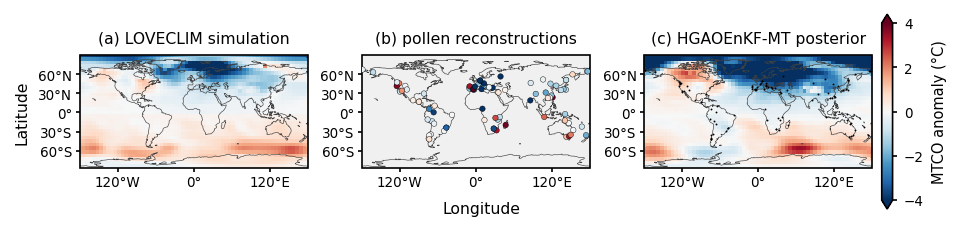

In [34]:
V = 4.0
masked = lambda f: np.where(safe_valid, f, np.nan)

# Panel titles carry identity only; what each panel means belongs in the LaTeX caption,
# where it can be read at full size rather than squeezed into a 2-inch column.
fig, axes = plt.subplots(1, 3, figsize=(REPORT_WIDTH, 1.45), subplot_kw={"projection": PLATE},
                         constrained_layout=True)

mesh = draw_field(axes[0], lats, lons, masked(sim_anom[CHAN_FIG11]), vmin=-V, vmax=V)
axes[0].set_title("(a) LOVECLIM simulation")

axes[1].set_facecolor("0.94")
axes[1].scatter(obs_lon, obs_lat, c=obs_anom, s=7, cmap="RdBu_r", vmin=-V, vmax=V,
                edgecolor="k", linewidth=0.2, transform=PLATE, zorder=3)
axes[1].set_title("(b) pollen reconstructions")

draw_field(axes[2], lats, lons, masked(post_anom[CHAN_FIG11]), vmin=-V, vmax=V)
axes[2].scatter(obs_lon, obs_lat, s=0.8, c="k", linewidth=0, transform=PLATE, zorder=3)
axes[2].set_title("(c) HGAOEnKF-MT posterior")

for i, ax in enumerate(axes):
    map_axes(ax, ylabel=(i == 0))
fig.supxlabel("Longitude", fontsize=7.5, y=0.02)

cb = fig.colorbar(mesh, ax=axes, shrink=0.95, pad=0.012, aspect=18, extend="both")
cb.set_label(f"{VARS[CHAN_FIG11].upper()} anomaly (°C)", fontsize=7)
cb.ax.tick_params(labelsize=6.5, length=2)
save(fig, "fig01_01_reconstruction_problem")
plt.show()

---

# Chapter 2 - Background and related work

## Figure 2.1 - the method-family map

A drawing, not an experiment: it reads nothing from disk and computes nothing. It places the
families Chapter 2 reviews on the two axes that actually separate them - **what the prior mean
is formed from** and **what the prior covariance is estimated from** - so that seven pages of
prose collapse into one object a reader can hold while reading Chapters 4 and 5.

Four decisions, each of which the caption has to carry or the figure misleads.

- **Both axes ask the same question about two different objects**, and share their vocabulary
  where they can: the *selected* states are the same states on both, which is exactly what an
  analog method does with them. Each axis is ordinal and runs in the order the chapter introduces the
  families, so a position states membership, not a distance; nothing may be interpolated
  between two boxes and no arithmetic on a coordinate means anything.
- **HGAOEnKF-MT sits in the same row and the same column band as HGAOEnKF**, with an arrow
  between them, and this is the point of the whole figure. The contribution keeps the analog
  mean and keeps the hybrid gain; what it changes is the *content* of the flow-dependent
  covariance. An earlier draft gave it a cell of its own above HGAOEnKF, which placed it
  visually inside the `a trained density` row and so said the opposite of Sections 2.4 and
  2.5 - that the contribution is a **learned** prior. It is non-Gaussian by construction, not
  by learning, and the figure must not be readable the other way.
- **The works are cited in the LaTeX caption, not inside the boxes.** The report uses
  Vancouver numbering, so an author-year list in a box buys a reader nothing, and those long
  labels were what forced every collision the layout previously had to work around.
- **AOEnKF-B is included even though nothing in this report runs it**, because it is the
  `hybrid_w = 0` corner that Section 6.5 pins the implementation against, and a reader who
  meets it there should already have seen where it sits. The caption glosses it.

The bottom two rows are genuinely different, and the distinction is load-bearing: LMR and
PHYDA draw one random ensemble and use its sample covariance, while pixel 3DVar and AOEnKF-B
form one covariance from the whole archive. That is the difference between Chapter 4's
baseline and the published paleoDA it is drawn from.


wrote ../outputs/figures/14_report_figures/fig02_01_method_family_map.png


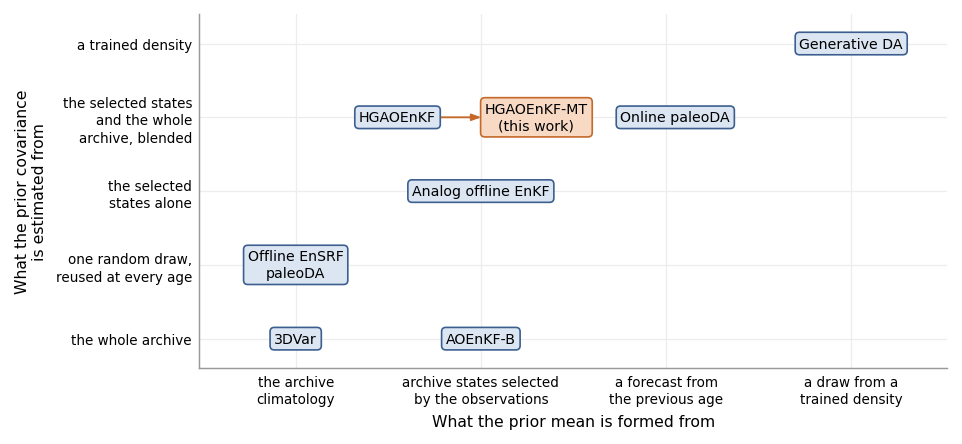

In [35]:
# Both axes ask one question about two different objects, so they share their vocabulary where
# they can: the selected states are the same states on both, which is exactly what an analog
# method does with them. Each axis is ordinal and runs in the order the chapter introduces the
# families, so a position carries membership, not a distance.
MEAN_AXIS = [
    "the archive\nclimatology",
    "archive states selected\nby the observations",
    "a forecast from\nthe previous age",
    "a draw from a\ntrained density",
]
COV_AXIS = [
    "the whole archive",
    "one random draw,\nreused at every age",
    "the selected\nstates alone",
    "the selected states\nand the whole\narchive, blended",
    "a trained density",
]

# Works are cited in the LaTeX caption, not in the boxes: the report numbers its references, so
# an author-year list here buys nothing, and those long labels were what forced every collision
# the layout used to work around. HGAOEnKF and HGAOEnKF-MT straddle their shared column so the
# connector between them has somewhere to go; everything else sits on its own tick.
METHODS = [
    (0.00, 0, "3DVar", "published"),
    (0.00, 1, "Offline EnSRF\npaleoDA", "published"),
    (1.00, 0, "AOEnKF-B", "published"),
    (1.00, 2, "Analog offline EnKF", "published"),
    (0.55, 3, "HGAOEnKF", "published"),
    (1.30, 3, "HGAOEnKF-MT\n(this work)", "ours"),
    (2.05, 3, "Online paleoDA", "published"),
    (3.00, 4, "Generative DA", "published"),
]

FACE = {"published": "#dce6f2", "ours": "#f7d9c4"}
EDGE = {"published": "#3c5f8f", "ours": "#c4692a"}

fig, ax = plt.subplots(figsize=(REPORT_WIDTH, 2.85), constrained_layout=True)
for y in range(len(COV_AXIS)):
    ax.axhline(y, color="0.93", lw=0.6, zorder=0)
for x in range(len(MEAN_AXIS)):
    ax.axvline(x, color="0.93", lw=0.6, zorder=0)

boxes = {}
for x, y, label, kind in METHODS:
    boxes[label.split("\n")[0]] = ax.annotate(
        label, (x, y), ha="center", va="center", zorder=3,
        fontsize=6.8, linespacing=1.25,
        bbox=dict(boxstyle="round,pad=0.30", facecolor=FACE[kind],
                  edgecolor=EDGE[kind], linewidth=0.8))

ax.set_xlim(-0.52, 3.52)
ax.set_ylim(-0.40, 4.40)
ax.set_xticks(range(len(MEAN_AXIS)), MEAN_AXIS, fontsize=6.5)
ax.set_yticks(range(len(COV_AXIS)), COV_AXIS, fontsize=6.5, linespacing=1.3)
ax.set_xlabel("What the prior mean is formed from", fontsize=7.5, labelpad=4)
ax.set_ylabel("What the prior covariance\nis estimated from", fontsize=7.5, labelpad=4)
ax.tick_params(length=0)
for _s in ("left", "bottom"):
    ax.spines[_s].set_color("0.6")
    ax.spines[_s].set_linewidth(0.7)


def box_edges(ann):
    """Left and right edge of a drawn annotation's box, in data coordinates.

    Hand-placing the connector meant guessing where the text ended, which left it stubbed
    against one border and floating off the other. Measuring the drawn patch lets it start and
    finish exactly on the two borders whatever the font metrics turn out to be.
    """
    fig.canvas.draw()
    bb = ann.get_bbox_patch().get_window_extent(fig.canvas.get_renderer())
    (x0, _), (x1, _) = ax.transData.inverted().transform([(bb.x0, bb.y0), (bb.x1, bb.y1)])
    return x0, x1


# A hair of overlap rather than an exact meeting, so no antialiasing seam shows at either end.
# The boxes are drawn above the connector, so none of it is visible inside them.
BITE = 0.004
_, hga_right = box_edges(boxes["HGAOEnKF"])
mt_left, _ = box_edges(boxes["HGAOEnKF-MT"])

# The contribution keeps the analog mean and keeps the hybrid gain, so it belongs in the same
# row and the same column band as the estimator it extends; only the content of the
# flow-dependent covariance changes. Putting it anywhere else on this map would misstate it -
# a box offset upward reads as belonging to the row above, which here is the learned prior the
# report explicitly rejects.
ax.annotate("", xy=(mt_left + BITE, 3.0), xytext=(hga_right - BITE, 3.0), zorder=2,
            arrowprops=dict(arrowstyle="-|>,head_length=0.5,head_width=0.18",
                            lw=0.9, color=EDGE["ours"], shrinkA=0, shrinkB=0))

save(fig, "fig02_01_method_family_map")
plt.show()


---

# Chapter 3 - The reconstruction problem: data and its character

Four figures and the numbers behind three tables. Everything here is recomputed from
`data/Prior.csv` and `data/Observation.csv` through the package loaders, so every quantity the
chapter prints traces to the same code the assimilation runs on rather than to a note.

The plan in `notes/final_report_plan.md` listed ten figures for this chapter. Six were cut
during drafting and the reasons belong on the record:

- The **innovation Gaussianity** panels and the **whitened-pair** panels (plan F3.6, F3.7) are
  in `outputs/figures/06_da_assumptions/`, authored at 10.9 in wide - one of them 24.8 in tall.
  Their content is carried in the main text by the six-row innovation-moments table instead,
  which states the same result more precisely in a fifth of the space. Notebook 06 remains the
  place those diagnostics are computed and looked at.
- The **CCSM4 210 / 170 ppm bimodality pair** (plan F3.8) is cut with it. It is a different
  model, a different grid and a different experiment; the chapter argues about the LOVECLIM
  archive the estimators actually draw their covariance from, and Figure 3.4 below is that
  argument made directly.
- The **latent-prior reconstruction floor** (plan F3.10) goes with Section 3.5, which was cut:
  the assimilation results that would have carried it are no longer on disk, and the analytic
  case against a learned prior is made in Chapter 2.

## Figure 3.1 - per-cell structure of the prior archive

Six maps on one page: what the simulation's mean state looks like, how much each cell moves
over the 20 kyr interval, and how much one snapshot tells you about the next.

Panels (a) and (d) are the climatology the anomaly frame is taken about. Panels (b) and (e)
are the reason that frame matters: the temporal standard deviation runs from a median of
0.58 degC (MTCO) and 0.73 degC (MTWA) to above 2.5 degC at the high latitudes, so an unweighted
fit in anomaly units is dominated by the North Atlantic and Southern Ocean cells where the D-O
signal lives. Panels (c) and (f) are the scarcity result of Section 3.3 in map form, and they
are what stops "the median cell has lag-1 autocorrelation 0.948" being read as an average over
a few extreme cells: it is high nearly everywhere. No quantity is derived from that median in
the chapter - see the note above Figure 3.3 for why the effective sample size it used to feed
was dropped.

Colour limits are fixed rather than data-driven so the two channels are comparable panel for
panel. The s.d. scale saturates above 3 degC, which affects a handful of polar cells only.

wrote ../outputs/figures/14_report_figures/fig03_01_prior_structure.png


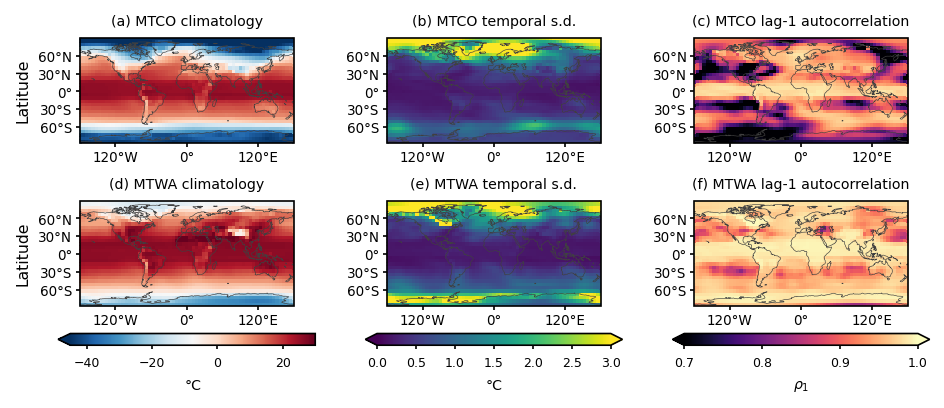

per-cell s.d. median 0.58 / 0.73 degC, 90th pct 2.49 / 2.83
per-cell rho1 median 0.9480 (mtco 0.900, mtwa 0.971), 5-95 pct [0.711, 0.990]


In [36]:
# The raw observation table as well as the long form: the dating range and the per-age site
# count are columns the long form drops, and both are Chapter 3 quantities.
raw = pd.read_csv(f"{DATA}/Observation.csv")
NCELL = len(lats) * len(lons)
mask_valid = lambda f: np.where(valid, f, np.nan)


def lag1_autocorr(x):
    """Per-cell lag-1 autocorrelation along the age axis.

    Pearson between the series and its own one-step shift, each half demeaned separately.
    Notebook 01 uses the biased form (one common mean, divided by the full sum of squares),
    which reads 0.003-0.005 lower per channel. The difference is immaterial to the chapter,
    which quotes the correlation itself and derives no other quantity from it.
    """
    a, b = x[:-1], x[1:]
    a = a - a.mean(0)
    b = b - b.mean(0)
    return (a * b).sum(0) / np.sqrt((a ** 2).sum(0) * (b ** 2).sum(0))


mean_all, std_all = cube.mean(axis=0), cube.std(axis=0)
r1 = np.stack([lag1_autocorr(cube[:, 0].astype(np.float64)),
               lag1_autocorr(cube[:, 1].astype(np.float64))])
r1_med = float(np.median(r1[:, valid]))

COLS = [("climatology", mean_all, dict(vmin=-45, vmax=30, cmap="RdBu_r"), "°C"),
        ("temporal s.d.", std_all, dict(vmin=0, vmax=3.0, cmap="viridis"), "°C"),
        ("lag-1 autocorrelation", r1, dict(vmin=0.7, vmax=1.0, cmap="magma"), r"$\rho_1$")]

fig, axes = plt.subplots(2, 3, figsize=(REPORT_WIDTH, 2.60), subplot_kw={"projection": PLATE},
                         constrained_layout=True)
for j, (label, field, kw, unit) in enumerate(COLS):
    for c, name in enumerate(VARS):
        mesh = draw_field(axes[c, j], lats, lons, mask_valid(field[c]), **kw)
        axes[c, j].set_title(f"({'adbecf'[2 * j + c]}) {name.upper()} {label}", fontsize=6.8)
        map_axes(axes[c, j], ylabel=(j == 0))
    cb = fig.colorbar(mesh, ax=axes[:, j], orientation="horizontal", shrink=0.92, pad=0.02,
                      aspect=22, extend="both" if j else "min")
    cb.set_label(unit, fontsize=6.8)
    cb.ax.tick_params(labelsize=6, length=2)
save(fig, "fig03_01_prior_structure")
plt.show()

print(f"per-cell s.d. median {np.median(std_all[0][valid]):.2f} / "
      f"{np.median(std_all[1][valid]):.2f} degC, 90th pct "
      f"{np.percentile(std_all[0][valid], 90):.2f} / {np.percentile(std_all[1][valid], 90):.2f}")
print(f"per-cell rho1 median {r1_med:.4f} (mtco {np.median(r1[0][valid]):.3f}, "
      f"mtwa {np.median(r1[1][valid]):.3f}), 5-95 pct "
      f"[{np.percentile(r1[:, valid], 5):.3f}, {np.percentile(r1[:, valid], 95):.3f}]")


## Figure 3.2 - the proxy network in space and in time

The figure Section 3.2 is written around, and the one that carries the sparsity claim better
than any number does.

- **(a)** every site, coloured by how many samples it contributes, over the grid cells the
  network reaches at any age in the record. The shaded cells are the whole of what an
  observation ever touches directly; the rest of the reconstruction is covariance.
- **(b)** how many sites report at each age. The network is not stationary: it runs from 4
  sites to 118, and the 36 youngest ages carry none at all.
- **(c)** the dating range each sample carries, `age_oldest - age_youngest` as Liu et al.
  report it. Strongly bimodal - a large group of tightly dated samples and a long tail.
- **(d)** how far, in years, an assimilated row sits from its own sample's block centre. This
  is the quantity the observation operator of Section 4.4 acts on, and it is **not** the same
  as (c): (c) is the uncertainty attached to a sample's date, (d) is the distance in time
  between where a sample is used and where it belongs. Counting is by assimilated row rather
  than by sample, because a widely replicated sample is used at many ages.

The map is drawn at the top of its own subfigure rather than as a gridspec row. A fixed-aspect
axes inside a mixed gridspec is sized by the layout solver to whatever height its row is given,
which left the world map at 60% of the text width; a subfigure lets it take the full width and
set its own height from the aspect.

wrote ../outputs/figures/14_report_figures/fig03_02_proxy_network.png


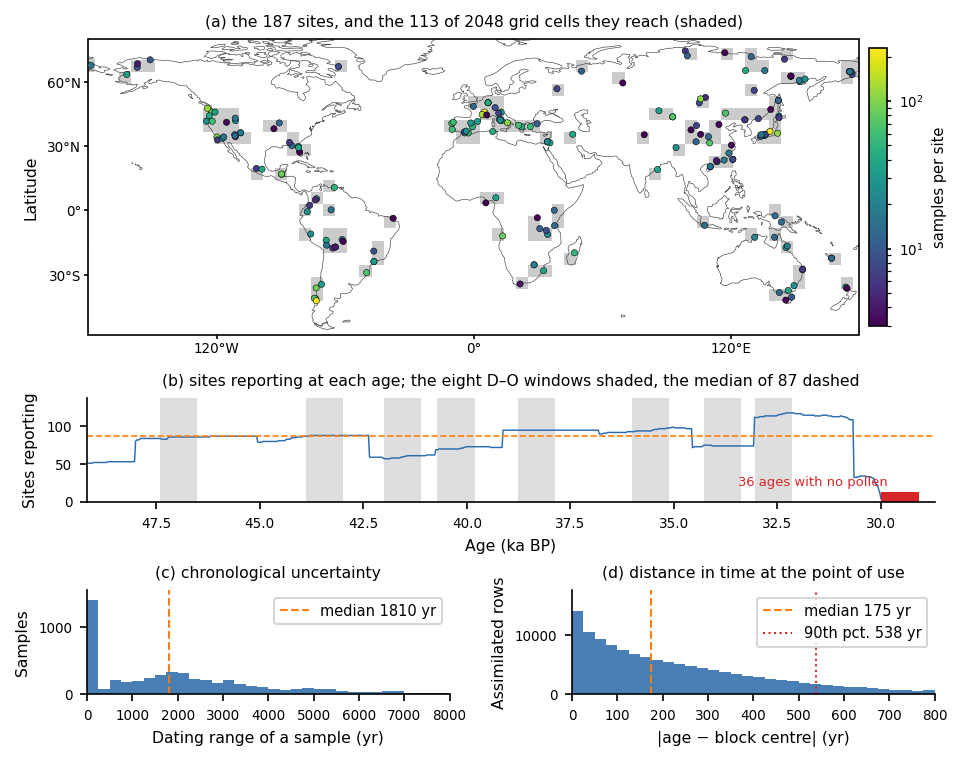

187 sites (139 NH, 74.3%), lat -42.17 to 74.47, lon -178.83 to 176.57
113/2048 cells (5.5%); sites per age median 87 (range 4-118); 36 empty ages, 29100-29975 yr BP
dating range: median 1810 yr, IQR 0-3220, max 24160
lag at use: median 175 yr, p90 538, max 1438, over 127646 rows


In [37]:
gidx = obs_cell_index(long["lat"].to_numpy(), long["lon"].to_numpy(),
                      long["channel"].to_numpy(), lats, lons) % NCELL
reached = np.zeros(NCELL, dtype=bool)
reached[np.unique(gidx)] = True
reached = reached.reshape(len(lats), len(lons))

sites = raw.groupby("siteID").agg(lat=("latitude", "first"), lon=("longitude", "first"),
                                  n=("sampleID", "nunique"))
per_age = raw.groupby("age")["siteID"].nunique()
free_ages = np.setdiff1d(ages, per_age.index.to_numpy())
date_range = (raw.drop_duplicates("sampleID").eval("age_oldest - age_youngest")).to_numpy()
lag_yr = sample_block_centres(long).eval("age - centre").abs().to_numpy()

fig = plt.figure(figsize=(REPORT_WIDTH, 4.95), layout="constrained")
sub_top, sub_bot = fig.subfigures(2, 1, height_ratios=[2.35, 2.60])

ax = sub_top.subplots(subplot_kw={"projection": PLATE})
# Fix the extent and freeze it before anything is drawn. The wrapped mesh at lon-360 would
# otherwise re-autoscale the axes and the layout solver would size the box to that wider
# aspect rather than to the world map actually shown.
ax.set_extent([-180, 180, -58, 80], crs=PLATE)
ax.set_autoscale_on(False)
draw_field(ax, lats, lons, np.where(reached, 1.0, np.nan), vmin=0, vmax=3.2, cmap="Greys")
ax.add_feature(cfeature.COASTLINE.with_scale("110m"), linewidth=0.3, edgecolor="0.25")
sc = ax.scatter(sites["lon"], sites["lat"], c=sites["n"], s=9, cmap="viridis",
                norm=plt.matplotlib.colors.LogNorm(), edgecolor="k", linewidth=0.25,
                transform=PLATE, zorder=3)
ax.set_xticks([-120, 0, 120], crs=PLATE)
ax.set_yticks([-30, 0, 30, 60], crs=PLATE)
ax.xaxis.set_major_formatter(LongitudeFormatter(zero_direction_label=False))
ax.yaxis.set_major_formatter(LatitudeFormatter())
ax.set_ylabel("Latitude")
ax.tick_params(length=2, pad=1.5)
ax.set_title(f"(a) the {len(sites)} sites, and the {int(reached.sum())} of {NCELL} "
             "grid cells they reach (shaded)")
cb = sub_top.colorbar(sc, ax=ax, shrink=0.94, pad=0.012, aspect=15)
cb.set_label("samples per site", fontsize=7)
cb.ax.tick_params(labelsize=6.5, length=2)

gs = sub_bot.add_gridspec(2, 2, height_ratios=[1.0, 1.0])
axb = sub_bot.add_subplot(gs[0, :])
for lo_, hi in DO_EVENT_WINDOWS.values():
    axb.axvspan(lo_ / 1000, hi / 1000, color="0.87", lw=0, zorder=0)
axb.plot(per_age.index.to_numpy() / 1000, per_age.to_numpy(), lw=0.7, color="#2b6cb0")
axb.axhline(per_age.median(), color="C1", lw=0.8, ls="--")
axb.plot(free_ages / 1000, np.full_like(free_ages, 6.0, dtype=float), lw=0, marker="|",
         ms=5, color="C3")
axb.annotate(f"{len(free_ages)} ages with no pollen", (free_ages.mean() / 1000, 6.0),
             textcoords="offset points", xytext=(-6, 4), ha="right", va="bottom",
             fontsize=6.3, color="C3")
axb.set_xlim(ages.max() / 1000, ages.min() / 1000 - 0.4)
axb.set_ylim(0, 138)
axb.set_xlabel("Age (ka BP)")
axb.set_ylabel("Sites reporting")
axb.set_title("(b) sites reporting at each age; the eight D–O windows shaded, "
              f"the median of {int(per_age.median())} dashed")

axc = sub_bot.add_subplot(gs[1, 0])
axc.hist(date_range, bins=np.arange(0, 8001, 250), color="#4a7fb5")
axc.axvline(np.median(date_range), color="C1", lw=1.0, ls="--",
            label=f"median {np.median(date_range):.0f} yr")
axc.set_xlim(0, 8000)
axc.set_ylim(0, 1550)
axc.set_xlabel("Dating range of a sample (yr)")
axc.set_ylabel("Samples")
axc.legend(loc="upper right")
axc.set_title("(c) chronological uncertainty")

axd = sub_bot.add_subplot(gs[1, 1])
axd.hist(lag_yr, bins=np.arange(0, 801, 25), color="#4a7fb5")
axd.axvline(np.median(lag_yr), color="C1", lw=1.0, ls="--",
            label=f"median {np.median(lag_yr):.0f} yr")
axd.axvline(np.percentile(lag_yr, 90), color="C3", lw=1.0, ls=":",
            label=f"90th pct. {np.percentile(lag_yr, 90):.0f} yr")
axd.set_xlim(0, 800)
axd.set_ylim(0, 17500)
axd.set_xlabel("|age − block centre| (yr)")
axd.set_ylabel("Assimilated rows")
axd.legend(loc="upper right")
axd.set_title("(d) distance in time at the point of use")
save(fig, "fig03_02_proxy_network")
plt.show()

nh = int((sites["lat"] > 0).sum())
print(f"{len(sites)} sites ({nh} NH, {100 * nh / len(sites):.1f}%), "
      f"lat {sites['lat'].min():.2f} to {sites['lat'].max():.2f}, "
      f"lon {sites['lon'].min():.2f} to {sites['lon'].max():.2f}")
print(f"{int(reached.sum())}/{NCELL} cells ({100 * reached.sum() / NCELL:.1f}%); "
      f"sites per age median {int(per_age.median())} (range {per_age.min()}-{per_age.max()}); "
      f"{len(free_ages)} empty ages, {free_ages.min()}-{free_ages.max()} yr BP")
print(f"dating range: median {np.median(date_range):.0f} yr, "
      f"IQR {np.percentile(date_range, 25):.0f}-{np.percentile(date_range, 75):.0f}, "
      f"max {date_range.max():.0f}")
print(f"lag at use: median {np.median(lag_yr):.0f} yr, p90 {np.percentile(lag_yr, 90):.0f}, "
      f"max {lag_yr.max():.0f}, over {lag_yr.size} rows")

## Figure 3.3 - the model-proxy offset, and how fast the archive renews itself

Two properties of the prior that the chapter needs and that no map shows.

- **(a)** LOVECLIM minus the pollen value at every co-located row, taking the nearest cell and
  the nearest age. The simulation sits above the reconstructions in both channels, and by very
  different amounts. This is the measurement that makes the anomaly frame a necessity rather
  than a convention, and the reason Chapter 1 says the fields "sit systematically warmer than
  the pollen implies".
- **(b)** two decorrelation curves against separation in time. The solid one is the mean cosine
  between whole 4096-dimensional anomaly states that far apart; the dashed one is the
  autocorrelation of the domain-mean anomaly, which is the more familiar quantity. The archive
  is a trajectory, and a trajectory at 25 yr spacing repeats itself.

**Why the state-vector curve is here at all.** An earlier draft of Section 3.3 summarised the
redundancy by an effective sample size, `N_eff = n(1-rho)/(1+rho) ~ 21.5`, taken from
`notes/final_report_plan.md`. That was dropped, and the reasons are worth keeping:

1. It is the equivalent number of independent observations for the **sample mean** of a
   stationary AR(1) sequence. Section 3.3 was applying it to a **covariance**, whose
   corresponding figure is `n(1-rho^2)/(1+rho^2)` - about 43 here, not 21.5. Both forms were
   confirmed by Monte Carlo on synthetic AR(1) before the change was made.
2. AR(1) does not describe these series. At a median-`rho` cell the empirical autocorrelation
   at 1000 yr is 0.76 where AR(1) predicts 0.11, because the archive is a forced trajectory
   with millennial structure. Running the sums empirically instead gives 4-13 rather than 21.5.
3. The answer depends heavily on which `rho` is fed in: the per-cell median gives 21.5, MTCO
   alone 42.5, MTWA alone 11.7, the leading PC score series 7.6, the domain mean 6.1.

The chapter now leads on the algebraic rank bound printed in the tables cell below, which needs
no model at all, and uses these curves as the measured statement that the states repeat each
other. Panel (a) is deliberately in raw degrees rather than anomalies, because the point of it
is the offset that the anomaly transform removes.

wrote ../outputs/figures/14_report_figures/fig03_03_offset_and_scarcity.png


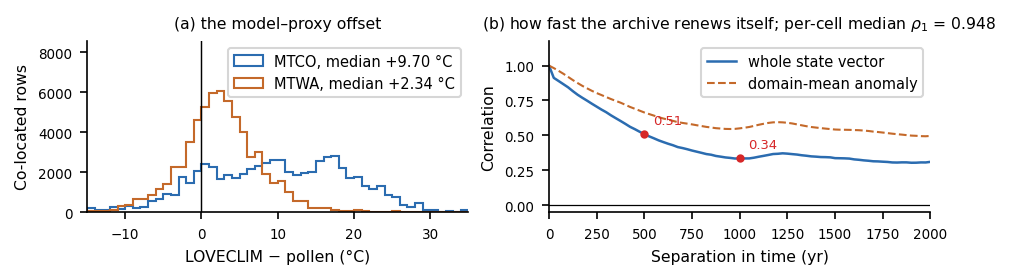

mtco: median +9.70 degC, MAD 7.34, 5-95% [-6.6, +24.1], n=63823
mtwa: median +2.34 degC, MAD 2.97, 5-95% [-6.0, +10.9], n=63823
domain-mean autocorrelation at 25 / 100 / 1000 yr: 0.9822 / 0.9192 / 0.5503
state-vector correlation at 25 / 500 / 1000 / 2000 yr: 0.912 / 0.509 / 0.335 / 0.310
state-vector correlation falls below 1/e at 825 yr and reaches zero at 6300 yr


In [38]:
def snap(values, axis):
    """Index of the nearest entry of a sorted ascending axis, for each value."""
    i = np.clip(np.searchsorted(axis, values), 1, len(axis) - 1)
    return np.where(values - axis[i - 1] < axis[i] - values, i - 1, i)


ai = snap(raw["age"].to_numpy(), ages)
la, lo_ = snap(raw["latitude"].to_numpy(), lats), snap(raw["longitude"].to_numpy(), lons)
resid = {"mtco": cube[ai, 0, la, lo_] - raw["mtco"].to_numpy(),
         "mtwa": cube[ai, 1, la, lo_] - raw["mtwa"].to_numpy()}

# Two decorrelation curves, both of the anomaly cube with the archive mean removed.
#
# The domain-mean series is one number per age, so its autocorrelation says how fast the
# archive's overall level changes. The state-vector curve is the mean cosine between whole
# 4096-dimensional anomaly states that many years apart, which is the object the covariance
# is estimated from and so the one Section 3.3 argues about. They are reported together
# because the second is the stronger statement and the first is the more familiar one.
A = (cube - cube.mean(axis=0, keepdims=True)).reshape(len(ages), -1).astype(np.float64)
dm = (cube - cube.mean(axis=0, keepdims=True))[:, :, valid].mean(axis=(1, 2))
dm = dm - dm.mean()
lags = np.arange(0, 81)
acf = np.array([1.0 if k == 0 else float((dm[:-k] * dm[k:]).sum() / (dm ** 2).sum())
                for k in lags])

# Mean correlation between whole state vectors at each separation: the mean of each
# off-diagonal of the Gram matrix of row-normalised anomaly states.
An = A / np.linalg.norm(A, axis=1, keepdims=True)
G = An @ An.T
svc = np.array([float(np.mean(np.diagonal(G, k))) for k in range(len(ages))])

fig, (axa, axb) = plt.subplots(1, 2, figsize=(REPORT_WIDTH, 1.75), constrained_layout=True)
for ch, col in zip(VARS, ("#2b6cb0", "#c4692a")):
    axa.hist(resid[ch], bins=np.arange(-15, 35.1, 1.0), histtype="step", lw=1.0, color=col,
             label=f"{ch.upper()}, median {np.median(resid[ch]):+.2f} °C")
axa.axvline(0, color="k", lw=0.7)
axa.set_xlim(-15, 35)
axa.set_ylim(0, 8600)
axa.set_xlabel("LOVECLIM − pollen (°C)")
axa.set_ylabel("Co-located rows")
axa.legend(loc="upper right")
axa.set_title("(a) the model–proxy offset")

axb.plot(lags * 25, svc[:81], lw=1.2, color="#2b6cb0", label="whole state vector")
axb.plot(lags * 25, acf, lw=1.0, ls="--", color="#c4692a", label="domain-mean anomaly")
axb.axhline(0, color="k", lw=0.6)
for yr in (500, 1000):
    k = yr // 25
    axb.plot([yr], [svc[k]], marker="o", ms=3, color="C3")
    axb.annotate(f"{svc[k]:.2f}", (yr, svc[k]), textcoords="offset points", xytext=(4, 5),
                 fontsize=6.3, color="C3")
axb.set_xlim(0, 2000)
axb.set_ylim(-0.05, 1.18)
axb.set_xlabel("Separation in time (yr)")
axb.set_ylabel("Correlation")
axb.legend(loc="upper right")
axb.set_title(f"(b) how fast the archive renews itself; "
              f"per-cell median $\\rho_1$ = {r1_med:.3f}")
save(fig, "fig03_03_offset_and_scarcity")
plt.show()

for ch in VARS:
    r = resid[ch]
    print(f"{ch}: median {np.median(r):+.2f} degC, "
          f"MAD {np.median(np.abs(r - np.median(r))):.2f}, "
          f"5-95% [{np.percentile(r, 5):+.1f}, {np.percentile(r, 95):+.1f}], n={r.size}")
print(f"domain-mean autocorrelation at 25 / 100 / 1000 yr: "
      f"{acf[1]:.4f} / {acf[4]:.4f} / {acf[40]:.4f}")
print(f"state-vector correlation at 25 / 500 / 1000 / 2000 yr: "
      f"{svc[1]:.3f} / {svc[20]:.3f} / {svc[40]:.3f} / {svc[80]:.3f}")
_efold = int(np.argmax(svc < np.exp(-1))) * 25
_zero = int(np.argmax(svc <= 0)) * 25
print(f"state-vector correlation falls below 1/e at {_efold} yr and reaches zero at {_zero} yr")


## Archive PC marginals - **cut from the report; kept as working**

**This figure is not in Chapter 3 and is referenced by no chapter.** The argument it was
built for - that the *archive* is bimodal, so a Gaussian prior destroys structure the
reconstruction needs - was measured and abandoned; the handover block of
`3.recon_problem.md` §2 records why, and the chapter now argues from the chronology
instead. The cell is kept rather than deleted because the numbers it prints are the answer
to the most likely viva questions about §3.4, and because Chapter 5 §5.5 uses the same
`pca_scores` machinery on the analog ensembles. `fig03_04_archive_pc_marginals.png` on
disk is therefore an orphan: nothing in the report includes it.

The 402 states of the PPE prior half are projected onto their own principal components and
each score is divided by its standard deviation, so the reference to compare against is
N(0,1) whatever the component's amplitude. By the Cramer-Wold device a distribution is
multivariate Gaussian only if *every* one-dimensional projection of it is univariate Gaussian,
so one visibly non-Gaussian projection is enough to falsify a Gaussian model of the archive.

Each title carries four numbers: the share of variance the component holds, the skewness, the
excess kurtosis, and the bimodality coefficient `BC = (skew^2 + 1) / (excess kurtosis + 3)`,
whose reference value for a uniform distribution is 5/9 = 0.556. A **negative** excess
kurtosis with BC above that threshold is the signature of a distribution with mass pushed
away from its centre, which is what two separated regimes look like along the axis that
separates them.

**Scope, stated once here and again in the chapter.** The archive is a transient trajectory
through slowly varying forcing, not a stationary sample, so this is not a claim that some
underlying glacial climate has a bimodal stationary density. It is a claim about the 402
states themselves: they occupy two separated clusters, and a single Gaussian centred on their
mean is a poor description of where they are. That is the object the covariance is estimated
from, so it is the object the claim needs to be about.

The occupancy fractions printed below are the direct substantiation of the assertion in
Chapter 2 Section 2.4.1 that a static prior sits at a mean the simulation spends little time
near.

The PCA is recomputed here rather than read from disk; it is deterministic and takes about a
second, and no lane stores it.

wrote ../outputs/figures/14_report_figures/fig03_04_archive_pc_marginals.png


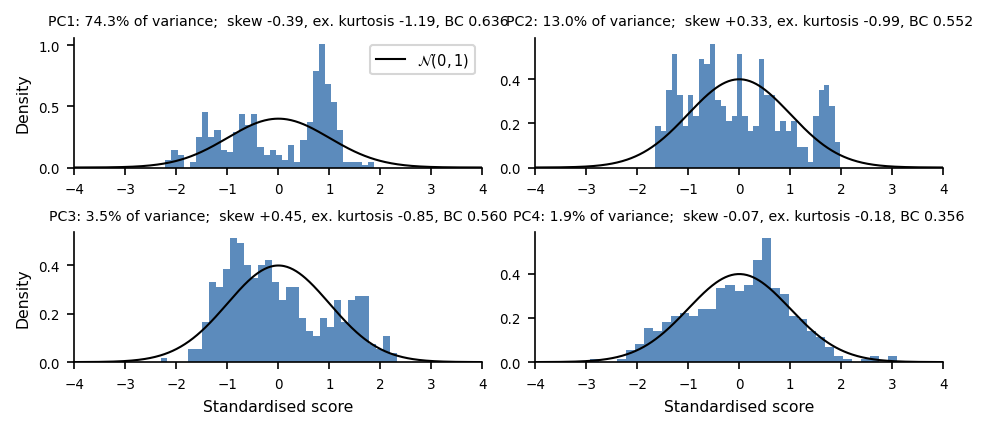

prior half: 402 states, 39150-49175 yr BP


,component,explained_variance,skew,excess_kurtosis,bimodality_coeff
0,PC1,0.7432,-0.3876,-1.1912,0.6359
1,PC2,0.1301,0.3296,-0.9898,0.5515
2,PC3,0.0353,0.4499,-0.8542,0.5604
3,PC4,0.0194,-0.0693,-0.1799,0.3563


BC threshold (uniform) = 0.5556
|PC1 z| < 0.25: 0.057 of the 402 states (a Gaussian would put 0.197 there)
|PC1 z| < 0.50: 0.154 of the 402 states (a Gaussian would put 0.383 there)
|PC1 z| < 1.00: 0.649 of the 402 states (a Gaussian would put 0.683 there)


In [39]:
BC_THRESHOLD = 5.0 / 9.0        # the uniform distribution's bimodality coefficient

prior_idx, _ = chronological_half_split(ages, stride=1)
pj = pca_scores(cube[prior_idx], 4)
z = pj["scores"] / pj["scores"].std(axis=0)
grid = np.linspace(-4, 4, 400)

fig, axes = plt.subplots(2, 2, figsize=(REPORT_WIDTH, 2.75), constrained_layout=True)
bimodality = []
for i, ax in enumerate(axes.ravel()):
    sk, ek = stats.skew(z[:, i]), stats.kurtosis(z[:, i])
    bc = (sk ** 2 + 1) / (ek + 3)
    bimodality.append({"component": f"PC{i + 1}",
                       "explained_variance": pj["explained_variance_ratio"][i],
                       "skew": sk, "excess_kurtosis": ek, "bimodality_coeff": bc})
    ax.hist(z[:, i], bins=34, density=True, color="#4a7fb5", alpha=0.9)
    ax.plot(grid, stats.norm.pdf(grid), color="k", lw=1.0,
            label="$\\mathcal{N}(0,1)$" if i == 0 else None)
    ax.set_xlim(-4, 4)
    ax.set_title(f"PC{i + 1}: {100 * pj['explained_variance_ratio'][i]:.1f}% of variance;  "
                 f"skew {sk:+.2f}, ex. kurtosis {ek:+.2f}, BC {bc:.3f}", fontsize=6.8)
    ax.set_xlabel("Standardised score" if i >= 2 else "")
    ax.set_ylabel("Density" if i % 2 == 0 else "")
    if i == 0:
        ax.legend(loc="upper right")
save(fig, "fig03_04_archive_pc_marginals")
plt.show()

print(f"prior half: {len(prior_idx)} states, {ages[prior_idx].min()}-{ages[prior_idx].max()} yr BP")
display(pd.DataFrame(bimodality).round(4))
print(f"BC threshold (uniform) = {BC_THRESHOLD:.4f}")

# How much time the trajectory spends near its own mean, along the axis that separates the
# two regimes: the substantiation of Chapter 2 Section 2.4.1.
for band in (0.25, 0.5, 1.0):
    frac = float((np.abs(z[:, 0]) < band).mean())
    print(f"|PC1 z| < {band:.2f}: {frac:.3f} of the {len(z)} states "
          f"(a Gaussian would put {2 * stats.norm.cdf(band) - 1:.3f} there)")

## Table 3.1

The dataset summary: the prior block and the observation block side by side, and every number
the chapter prints that is not already in a figure title.

**Two tables that were planned here are not.** The innovation moments have moved to the
**Chapter 5** section below, because they are a statement about *3DVar's* error assumptions and
belong beside the estimator whose assumptions they test. The bimodality statistics went with
the argument they supported; see the cell above.

Also computed here: the per-channel representativeness variance that Section 5.4 puts into `R`,
and the size of the per-site anomaly frame's departure from a full-record climatology. The
latter has no direct estimator, because a site that stops reporting halfway through the record
never states what its mean over the whole record would have been; the model is used as the
stand-in, taking each site's cell in LOVECLIM and comparing its mean over the ages that site
reports at against its mean over all 804.

Building the full `(4096, 4096)` background covariance takes a few seconds and about 130 MB.
Only its diagonal is needed, and it is released immediately afterwards.

In [40]:
D = len(VARS) * len(lats) * len(lons)
samples = collapse_to_samples(long)          # one row per (site, channel, sample)

print("--- Table 3.1: the prior ---")
print(f"grid {len(lats)}x{len(lons)} at {CELL_DEG} deg; channels {VARS}; D = {D}")
print(f"{len(ages)} states, {ages.min()}-{ages.max()} yr BP at "
      f"{int(np.unique(np.diff(ages))[0])} yr spacing; "
      f"valid cells {int(valid.sum())}/{valid.size}")
print(f"covariance entries {D * D:,}; free parameters D(D+1)/2 = {D * (D + 1) // 2:,}")

# What a sample covariance from N states can possibly be. The rank bound N-1 is algebraic and
# needs no assumption about the archive; it is what Section 3.3 leads with, in place of the
# effective-sample-size figure an earlier draft carried. The numerical rank is printed beside
# it to confirm the bound is attained rather than merely bounding.
for label, idx in (("all states", np.arange(len(ages))),
                   ("prior half", chronological_half_split(ages, stride=1)[0])):
    Ac = cube[idx].reshape(len(idx), -1).astype(np.float64)
    Ac = Ac - Ac.mean(0)
    ev = np.linalg.svd(Ac, compute_uv=False) ** 2 / (len(idx) - 1)
    cum = np.cumsum(ev) / ev.sum()
    print(f"  {label}: N = {len(idx)}, rank(B_hat) <= N-1 = {len(idx) - 1} of D = {D} "
          f"({(len(idx) - 1) / D:.1%} of directions); numerical rank "
          f"{int((ev > ev[0] * 1e-10).sum())}; "
          f"eigenvalues holding 90/99% of the trace: "
          f"{int(np.searchsorted(cum, 0.90)) + 1}/{int(np.searchsorted(cum, 0.99)) + 1}")
print("--- Table 3.1: the observations ---")
print(f"{long['site'].nunique()} sites, {long['sample'].nunique()} samples, "
      f"{len(long):,} long-format rows, {long['age'].nunique()} of {len(ages)} ages covered")
print(f"median sse: " + ", ".join(
    f"{ch} {samples[samples.channel == ch]['sse'].median():.2f} degC^2" for ch in VARS))

# Representativeness variance: co-cell, co-age proxy pairs with each proxy's own stated error
# removed. Estimated over the assimilated rows, which is how run_withholding estimates it.
rep_cell = obs_cell_index(long["lat"].to_numpy(), long["lon"].to_numpy(),
                          long["channel"].to_numpy(), lats, lons) % NCELL
rep_var = representativeness_variance(long, rep_cell)
print("representativeness variance: " + ", ".join(f"{k} {v:.2f} degC^2" for k, v in rep_var.items()))

# The per-site anomaly frame against a full-record climatology, with the model as stand-in.
flat = cube.reshape(len(ages), -1).astype(np.float64)
full_mean = flat.mean(axis=0)
samples_g = samples.assign(g=obs_cell_index(samples["lat"].to_numpy(), samples["lon"].to_numpy(),
                                            samples["channel"].to_numpy(), lats, lons))
offset = np.array([flat[np.clip(np.searchsorted(ages, s["age"].to_numpy()), 0, len(ages) - 1),
                        int(s["g"].iloc[0])].mean() - full_mean[int(s["g"].iloc[0])]
                   for _, s in samples_g.groupby(["site", "channel"])])
span = samples.groupby(["site", "channel"])["age"].agg(lambda a: (a.max() - a.min()))
print(f"site-frame offset vs full climatology: rms {np.sqrt((offset ** 2).mean()):.3f} degC, "
      f"median |.| {np.median(np.abs(offset)):.3f}, over {offset.size} site-channel records; "
      f"{(span / (ages.max() - ages.min()) < 0.5).mean():.2f} of records span under half the interval")


--- Table 3.1: the prior ---
grid 32x64 at 5.625 deg; channels ('mtco', 'mtwa'); D = 4096
804 states, 29100-49175 yr BP at 25 yr spacing; valid cells 2048/2048
covariance entries 16,777,216; free parameters D(D+1)/2 = 8,390,656
  all states: N = 804, rank(B_hat) <= N-1 = 803 of D = 4096 (19.6% of directions); numerical rank 803; eigenvalues holding 90/99% of the trace: 3/40
  prior half: N = 402, rank(B_hat) <= N-1 = 401 of D = 4096 (9.8% of directions); numerical rank 401; eigenvalues holding 90/99% of the trace: 3/48
--- Table 3.1: the observations ---
187 sites, 5384 samples, 127,646 long-format rows, 768 of 804 ages covered
median sse: mtco 1.07 degC^2, mtwa 0.96 degC^2
representativeness variance: mtco 0.70 degC^2, mtwa 0.00 degC^2
site-frame offset vs full climatology: rms 0.354 degC, median |.| 0.134, over 374 site-channel records; 0.52 of records span under half the interval


---

# Chapter 4 - Experimental design

**The chapter order changed on 2026-09-08: experimental design moved from position 6 to
position 4, ahead of both method chapters.** Baseline estimators is now Chapter 5 and
HGAOEnKF-MT Chapter 6. The reason is that neither method chapter merely mentions the lanes -
every skill table in both *is* a lane result, and a reader cannot audit one without knowing
what a selection split is.

This chapter carries **no figures**. It has two tables, both largely written by hand: T4.1,
the three lanes at a glance, and T4.2, the metric definitions (Appendix D). The cell below
supplies the parts of them that should be read off the artefacts rather than retyped - how
big each lane actually is, and the prior-free `nearest` / `idw` reference points that Section
4.2 defines.

Those reference points are the reason this section exists at all. On the withholding lane CE
is small by construction, so a reader who meets 0.08 with nothing to compare it against reads
it as failure; inverse-distance weighting scores -0.04 on the same lane, and that is the
number that makes the first one legible.

In [41]:
# Everything Chapter 4 needs that is not written by hand: the size of each lane, and the
# prior-free reference points its metrics section defines. Nothing here runs an estimator;
# each block opens a lane's config and its metrics CSV.
#
# One reading rule governs every withholding number in this notebook and in Chapters 4-7.
# That lane writes one row per fold *and* a row pooled over folds at `fold = -1`. The pooled
# row is the one the report quotes; averaging it together with the five per-fold rows shifts
# every withholding figure by a few thousandths, which is enough to change a reported CE.
FOLD_POOLED = -1


def lane_rows(directory):
    """One lane directory's metrics, restricted to the rows the report quotes."""
    m = pd.read_csv(OUT / directory / "metrics.csv")
    return m[(m.channel == "pooled") & (m.do_event == "all") & (m.fold == FOLD_POOLED)]


# --- Table 4.1: how big each lane is -------------------------------------------------------
# The prose must not repeat these; they belong in the table.
ppe = json.load(open(OUT / "3dvar_pixel" / "ppe_config.json"))
wh = json.load(open(OUT / "3dvar_pixel" / "withholding_random_config.json"))
traj = json.load(open(OUT / "3dvar_pixel_trajectory" / "trajectory_config.json"))

print("--- Table 4.1: lane sizes ---")
print(f"pseudo-proxy : {ppe['n_truths']} truths x {ppe['n_shapes']} network shapes x "
      f"{ppe['n_noise']} noise draws; {ppe['n_select']} shapes select, "
      f"{ppe['n_shapes'] - ppe['n_select']} reports; prior = "
      f"{ppe['prior_meta']['n_prior_ages']} states of the {ppe['prior_half']} half, "
      f"truths from the other; R = diag(sse)")
print(f"trajectory   : {traj['n_covered_ages']} consecutive ages reconstructed "
      f"({traj['n_skipped_ages']} skipped for too few observations), 1 noise draw per age; "
      f"selection {traj['selection_ages']}, test {traj['test_ages']} yr BP; "
      f"prior = {traj['prior_meta']['n_prior_ages']} states")
print(f"withholding  : {wh['k_folds']} {wh['fold_kind']} site folds; prior = "
      f"{wh['prior_meta']['n_prior_ages']} states spanning every age; "
      f"R = diag(sse + rep_var), rep_var {wh['rep_var_full']}")

# --- Section 4.2: the prior-free reference points ------------------------------------------
# `nearest` copies each cell's nearest observation, `idw` weights by inverse square distance;
# neither uses the model. They are what makes a withholding CE readable: on that lane CE is
# small by construction, so it has to be read against these rather than against 1.
LANES = [("pseudo-proxy", "3dvar_pixel", "ppe"),
         ("trajectory", "3dvar_pixel_trajectory", "trajectory"),
         ("withholding", "3dvar_pixel", "withholding_random")]
rows = []
for label, directory, lane in LANES:
    m = lane_rows(directory)
    m = m[(m.lane == lane) & (m.split == "test") & (m.metric.isin(["rrmse", "ce", "amplitude"]))]
    for method in ("nearest", "idw"):
        sub = m[m.method == method]
        if len(sub):
            rows.append({"lane": label, "method": method,
                         **sub.groupby("metric")["value"].mean().to_dict()})
print("\n--- Section 4.2: prior-free reference points, test split ---")
display(pd.DataFrame(rows).set_index(["lane", "method"]).round(4))

--- Table 4.1: lane sizes ---
pseudo-proxy : 41 truths x 5 network shapes x 5 noise draws; 4 shapes select, 1 reports; prior = 402 states of the older half, truths from the other; R = diag(sse)
trajectory   : 365 consecutive ages reconstructed (37 skipped for too few observations), 1 noise draw per age; selection [30025, 34550], test [34575, 39125] yr BP; prior = 402 states
withholding  : 5 random site folds; prior = 804 states spanning every age; R = diag(sse + rep_var), rep_var {'mtco': 0.6950619541444355, 'mtwa': 0.0}

--- Section 4.2: prior-free reference points, test split ---


amplitude      ce   rrmse
lane         method                            
pseudo-proxy nearest     0.9520  0.0632  0.9679
             idw         0.4628  0.3300  0.8185
trajectory   nearest     1.3425 -0.9962  1.4533
             idw         0.4810  0.1818  0.9304
withholding  nearest     0.9428 -0.4595  1.2081
             idw         0.6381 -0.0413  1.0205

---

# Chapter 5 - Baseline estimators

The two published estimators the contribution is built on and measured against, plus this
project's own treatment of the observation operator in time. Nothing in the chapter is claimed
as a contribution, so nothing here is drawn in the colour reserved for what this work adds.

**Two figures and two tables.** Both tables (T5.1, the pixel taper and operating point per lane;
T5.2, the analog selection rules on the pseudo-proxy lane) are written by hand in the chapter
file from the numbers the cell below prints, exactly as Chapter 4's two tables are. The figures
are produced here.

Two errors in `notes/final_report_plan.md` are worth not rediscovering, both found by a draft
that was written on 2026-09-08 and discarded with the restructure: the withholding lane's
selected background amplitude is **5, not 2** (`3dvar_pixel/withholding_random_config.json`),
and the analog-lengthscale comparison the plan labels "evidence" is the **flow-augmented**
estimator rather than evidence selection alone.

**Three planned figures were dropped** and are not produced here: the pixel tuning landscape,
the analog selection surface, and the analog-set stability plot. All three exist under
`outputs/figures/` but at 20.9, 6.15 and 8.9 in wide against the report's 6.3 in, so each would
have needed re-authoring; none carried an argument the prose could not make in a sentence, and
the six-page budget did not have room. The stability plot is the one worth reviving, in
Chapter 7 rather than here, because it is the mechanism behind that chapter's negative
fast-band CE.


## Figure 5.1 - the two estimators, side by side

A drawing: it reads nothing from disk. It exists so that Chapter 6's estimator can be shown as
a modification of panel (b) rather than described from scratch, so **the visual conventions here
are a commitment**:

- **Four roles, one colour each.** Blue is the static, archive-wide path; green is the
  data-selected, flow-dependent path; grey is the observations and anything that consumes them
  directly; white is the analysis. **Orange (`#c4692a` / `#f7d9c4`) is reserved for what this
  project adds** and is deliberately unused in this figure, matching Figure 2.1's use of it.
- **One estimator per row, read left to right**, at `REPORT_WIDTH` and about 1.6 in tall.
  Chapter 6 draws panel (c) as one more row in the same frame.
- **The prior mean is a dashed path along the bottom, not a box.** That is the single clearest
  contrast between the two panels and it should stay that way: 3DVar's runs from the archive
  and carries the climatology, HGAOEnKF's runs from the selected states and carries their mean.
- Solid arrows are objects flowing forward; the dashed path is the background the increment is
  added to.


wrote ../outputs/figures/14_report_figures/fig05_01_estimator_schematic.png


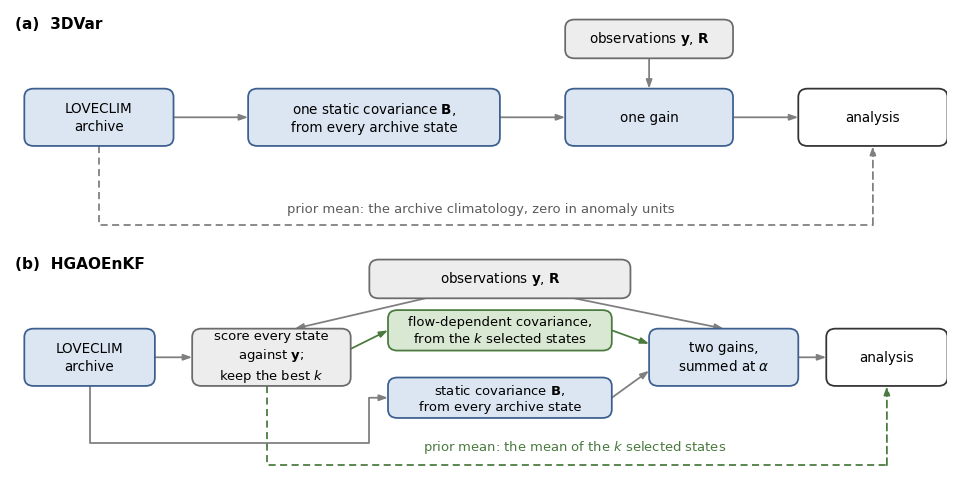

In [42]:
# A drawing, not an experiment. The four roles below are the visual language Chapter 6's
# panel (c) has to be drawn in, so they are named here rather than inlined: blue is the
# static archive-wide path, green the data-selected flow-dependent one, grey the observations
# and whatever consumes them directly, white the analysis. Orange is Figure 2.1's "this work"
# colour and is deliberately absent, because nothing in this chapter is ours.
from matplotlib.patches import FancyBboxPatch

STATIC = ("#dce6f2", "#3c5f8f")
FLOW = ("#d9e8d3", "#4a7a3f")
DATA = ("#ededed", "#6b6b6b")
ANALYSIS = ("#ffffff", "#333333")
CONNECT = "#7f7f7f"
ARROW = dict(arrowstyle="-|>,head_length=0.45,head_width=0.16", lw=0.85,
             color=CONNECT, shrinkA=0, shrinkB=0)
DASHED = (0, (4, 2.5))

# Both panels share one coordinate frame, so a box of a given height renders at the same
# physical size in each; a reader compares them by looking, and unequal scales would break
# that. The empty band under panel (a) is the price and is deliberate.
ROW0, ROW1 = 5.4, 8.8           # the main left-to-right flow
MID = (ROW0 + ROW1) / 2
OBS0, OBS1 = 10.6, 12.9         # the observation node, above the flow
MEAN_Y = 0.7                    # the prior-mean path, below it


def stage(ax, x0, x1, y0, y1, text, style, fs=6.5):
    """One labelled object in the flow. Returns its box for the arrows to attach to."""
    face, edge = style
    ax.add_patch(FancyBboxPatch((x0, y0), x1 - x0, y1 - y0, mutation_aspect=0.5,
                                boxstyle="round,pad=0,rounding_size=1.0", facecolor=face,
                                edgecolor=edge, linewidth=0.85, zorder=3))
    ax.text((x0 + x1) / 2, (y0 + y1) / 2, text, ha="center", va="center", fontsize=fs,
            linespacing=1.32, zorder=4)
    return (x0, x1, y0, y1)


def flow(ax, start, end, **kw):
    opts = dict(ARROW)
    opts.update(kw)
    ax.annotate("", xy=end, xytext=start, arrowprops=opts, zorder=2)


def route(ax, xs, ys, color=CONNECT, **kw):
    """An elbowed connector, drawn under every box so it can pass behind one."""
    ax.plot(xs, ys, color=color, lw=0.85, zorder=1, solid_capstyle="round", **kw)


fig, axes = plt.subplots(2, 1, figsize=(REPORT_WIDTH, 3.2), constrained_layout=True)
for ax in axes:
    ax.set_xlim(0, 100)
    ax.set_ylim(-0.3, 13.2)
    ax.axis("off")

# --- (a) pixel 3DVar: one covariance, one gain, a background that never moves --------------
ax = axes[0]
ax.text(0, 13.1, "(a)  3DVar", fontsize=7.4, fontweight="bold", va="top")
archive = stage(ax, 1, 17, ROW0, ROW1, "LOVECLIM\narchive", STATIC)
cov = stage(ax, 25, 52, ROW0, ROW1,
            "one static covariance $\\mathbf{B}$,\nfrom every archive state", STATIC)
gain = stage(ax, 59, 77, ROW0, ROW1, "one gain", STATIC)
out = stage(ax, 84, 100, ROW0, ROW1, "analysis", ANALYSIS)
obs = stage(ax, 59, 77, OBS0, OBS1, "observations $\\mathbf{y}$, $\\mathbf{R}$", DATA)
for left, right in ((archive, cov), (cov, gain), (gain, out)):
    flow(ax, (left[1], MID), (right[0], MID))
flow(ax, (68, OBS0), (68, ROW1))
route(ax, [9, 9, 92], [ROW0, MEAN_Y, MEAN_Y], ls=DASHED)
flow(ax, (92, MEAN_Y), (92, ROW0), ls=DASHED)
ax.text(50, MEAN_Y + 0.55, "prior mean: the archive climatology, zero in anomaly units",
        fontsize=6.3, color="#5c5c5c", ha="center", va="bottom")

# --- (b) HGAOEnKF: the observations choose the ensemble, and there are two of everything ---
ax = axes[1]
ax.text(0, 13.1, "(b)  HGAOEnKF", fontsize=7.4, fontweight="bold", va="top")
archive = stage(ax, 1, 15, ROW0, ROW1, "LOVECLIM\narchive", STATIC)
select = stage(ax, 19, 36, ROW0, ROW1,
               "score every state\nagainst $\\mathbf{y}$;\nkeep the best $k$", DATA, fs=6.3)
cov_flow = stage(ax, 40, 64, 7.5, 9.9,
                 "flow-dependent covariance,\nfrom the $k$ selected states", FLOW, fs=6.3)
cov_static = stage(ax, 40, 64, 3.5, 5.9,
                   "static covariance $\\mathbf{B}$,\nfrom every archive state", STATIC, fs=6.3)
gain = stage(ax, 68, 84, ROW0, ROW1, "two gains,\nsummed at $\\alpha$", STATIC)
out = stage(ax, 87, 100, ROW0, ROW1, "analysis", ANALYSIS)
obs = stage(ax, 38, 66, OBS0, OBS1, "observations $\\mathbf{y}$, $\\mathbf{R}$", DATA)
flow(ax, (archive[1], MID), (select[0], MID))
flow(ax, (44, OBS0), (30, ROW1))
flow(ax, (60, OBS0), (76, ROW1))
flow(ax, (select[1], 7.6), (cov_flow[0], 8.7), color=FLOW[1])
# The static covariance is built from the whole archive and never sees the selection, so its
# connector has to leave the archive before the scoring box rather than pass through it.
route(ax, [8, 8, 38, 38], [ROW0, 2.0, 2.0, 4.7])
flow(ax, (38, 4.7), (cov_static[0], 4.7))
flow(ax, (cov_flow[1], 8.7), (gain[0], 7.9), color=FLOW[1])
flow(ax, (cov_static[1], 4.7), (gain[0], 6.3))
flow(ax, (gain[1], MID), (out[0], MID))
route(ax, [27, 27, 93.5], [ROW0, MEAN_Y, MEAN_Y], color=FLOW[1], ls=DASHED)
flow(ax, (93.5, MEAN_Y), (93.5, ROW0), color=FLOW[1], ls=DASHED)
ax.text(60, MEAN_Y + 0.55, "prior mean: the mean of the $k$ selected states",
        fontsize=6.3, color=FLOW[1], ha="center", va="bottom")

save(fig, "fig05_01_estimator_schematic")
plt.show()


## Figure 5.2 - the lag correlation the observation operator uses

The one figure in Chapter 5 that is a measurement. A sample is replicated across its whole dating
block, so at most ages it reports on a state some way off in time; the prior's own temporal
structure function says how much of that state it still carries.

One panel: the correlation itself, `rho = 1 - S / (2 var)`, floored at 0.05, against the lag,
for the whole grid (median and 10th-90th percentile band) and three representative cells. It is
estimated from the **prior half alone**, which is the leakage guard: on a lane whose truth is a
model state, later ages would leak that truth into the operator that reconstructs it. The two
dotted lines are the median (175 yr) and 90th-percentile (537.5 yr) distances a real assimilated
row actually sits from its own sample, from Chapter 3.

**An earlier version carried a second panel**, showing what `add` and `deflate` charge for the lag
as a multiple of a site's error variance. It was cut on 2026-09-11 at the author's request; the
`add`-versus-`deflate` argument now rests on the algebra of Section 5.3 instead.


wrote ../outputs/figures/14_report_figures/fig05_02_lag_correlation.png


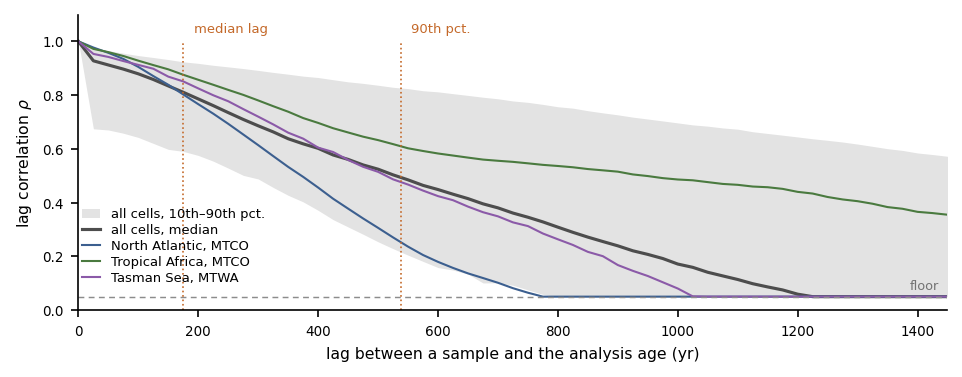

North Atlantic, MTCO     rho at 175 yr 0.80, at 538 yr 0.25
Tropical Africa, MTCO    rho at 175 yr 0.88, at 538 yr 0.61
Tasman Sea, MTWA         rho at 175 yr 0.85, at 538 yr 0.48
all cells, median        rho at 175 yr 0.81, at 538 yr 0.49, at 1000 yr 0.17


In [43]:
# Imported here rather than at the top: this is the only figure in the report that reads the
# archive along its age axis rather than across the grid, and keeping the import beside it
# says so.
from paleoreco.assim.background import temporal_structure_function

RHO_FLOOR = 0.05                # observations.temporal_terms floors rho here
MEDIAN_LAG, P90_LAG = 175.0, 537.5      # Section 3.2.2, over all 127,646 assimilated rows
MARK = "#c4692a"

# The prior half alone, which is the leakage guard the trajectory lane runs under: on a lane
# whose truth is a model state, later ages would leak that truth into the operator that
# corrects for the distance to it.
prior_idx, _ = chronological_half_split(ages, stride=1)
S, cell_var = temporal_structure_function(cube, prior_idx, max_lag=58)
lag_yr = np.arange(S.shape[0]) * 25.0
rho = np.clip(1.0 - S / (2.0 * cell_var[None, :]), RHO_FLOOR, 1.0)

n_cells = len(lats) * len(lons)


def flat_index(lat, lon, channel):
    """Row of the flattened state vector nearest one (lat, lon) in one channel."""
    i = int(np.argmin(np.abs(np.asarray(lats) - lat)))
    j = int(np.argmin(np.abs(np.asarray(lons) - lon)))
    return channel * n_cells + i * len(lons) + j


# Three cells spanning the range the shaded band summarises: the North Atlantic, where the
# D-O signal and most of the archive's variance live and where a state renews itself fastest;
# a quiet tropical cell; and a mid-latitude Southern Hemisphere cell in the other channel.
SHOWN = [("North Atlantic, MTCO", flat_index(62, -20, 0), "#3c5f8f"),
         ("Tropical Africa, MTCO", flat_index(2, 20, 0), "#4a7a3f"),
         ("Tasman Sea, MTWA", flat_index(-40, 145, 1), "#8b5aa8")]

fig, ax = plt.subplots(figsize=(REPORT_WIDTH, 2.4), constrained_layout=True)

q10, q50, q90 = np.percentile(rho, [10, 50, 90], axis=1)
ax.fill_between(lag_yr, q10, q90, color="0.89", lw=0, label="all cells, 10th–90th pct.")
ax.plot(lag_yr, q50, color="0.30", lw=1.5, label="all cells, median")
for name, idx, colour in SHOWN:
    ax.plot(lag_yr, rho[:, idx], color=colour, lw=1.0, label=name)
ax.axhline(RHO_FLOOR, color="0.55", lw=0.7, ls=(0, (4, 3)))
ax.text(1435, RHO_FLOOR + 0.015, "floor", color="0.45", fontsize=6.2, ha="right", va="bottom")
for x, label in ((MEDIAN_LAG, "median lag"), (P90_LAG, "90th pct.")):
    ax.plot([x, x], [0, 1.0], color=MARK, lw=0.8, ls=":")
    ax.text(x + 18, 1.045, label, color=MARK, fontsize=6.3, va="center", ha="left")
ax.set_xlim(0, 1450)
ax.set_ylim(0, 1.10)
ax.set_xlabel("lag between a sample and the analysis age (yr)")
ax.set_ylabel(r"lag correlation $\rho$")
# One panel, so no panel label: what it shows belongs in the LaTeX caption.
ax.legend(loc="lower left", frameon=False, handlelength=1.4, borderpad=0.1,
          labelspacing=0.22, fontsize=6.3, bbox_to_anchor=(-0.005, 0.06))

save(fig, "fig05_02_lag_correlation")
plt.show()

# The three numbers Section 5.3 quotes, so the prose is read off the same object as the figure.
for name, idx, _ in SHOWN:
    print(f"{name:24s} rho at {MEDIAN_LAG:.0f} yr {np.interp(MEDIAN_LAG, lag_yr, rho[:, idx]):.2f}, "
          f"at {P90_LAG:.0f} yr {np.interp(P90_LAG, lag_yr, rho[:, idx]):.2f}")
print(f"{'all cells, median':24s} rho at {MEDIAN_LAG:.0f} yr {np.interp(MEDIAN_LAG, lag_yr, q50):.2f}, "
      f"at {P90_LAG:.0f} yr {np.interp(P90_LAG, lag_yr, q50):.2f}, "
      f"at 1000 yr {np.interp(1000, lag_yr, q50):.2f}")


## Innovation moments - **kept as working, not printed in the report**

**This table is not in Chapter 5.** It was handed over complete in Chapter 3's handover and the
cell is kept because it is the answer to a likely viva question, but the chapter prints none of
it. Two reasons: nothing downstream depends on it, and its headline number cannot be printed
without a paragraph of hedging, since the pooled excess kurtosis of 12.60 is largely a scale
mixture across ages (within-age median +1.31) rather than heavy tails within any one age. The
robust result is the over-dispersion - per-age median standardised spread 1.617 - and Chapter 5
makes that point instead from the rank argument of Section 3.3, which needs no table.

It is notebook 06 cell 7 re-run. The agreement of the `anomaly` and `normalised` rows is a
correctness check on the transforms, not a redundant row, and it is asserted rather than merely
displayed.


In [44]:
# Imported here rather than at the top: nothing else in this notebook forms an innovation,
# and keeping the machinery beside the one table that uses it says so.
from paleoreco.data.cube import compute_zscore_stats
from paleoreco.assim import scoring as sc
from paleoreco.assim.background import (
    background_covariance, background_state, background_variance,
)
from paleoreco.assim.innovation import (
    innovation, obs_operator_scale, predicted_sd, standardise,
)

# --- Table 5.2: innovation moments ---------------------------------------------------------
stats_z = compute_zscore_stats(cube, np.arange(len(ages)), valid)
mean_flat = stats_z["mean"].ravel().astype(float)
safe_flat = np.broadcast_to(stats_z["safe_valid"], (len(VARS), len(lats), len(lons))).ravel()
B = background_covariance(cube, np.arange(len(ages)))
diagB = background_variance(B)
del B
sigma_x = np.sqrt(diagB)
obs_ages = np.intersect1d(samples["age"].unique(), ages)


def pool_z(kind, mode):
    """Standardised innovations pooled over every age that carries an observation."""
    zs = []
    for age_ in obs_ages:
        o = observations_at_age(samples, int(age_))
        g = obs_cell_index(o["lat"], o["lon"], o["channel"], lats, lons)
        keep = safe_flat[g] & (o["sy"] > 1e-8)
        if not keep.any():
            continue
        g = g[keep]
        y, sse, my, sy = o["y"][keep], o["sse"][keep], o["my"][keep], o["sy"][keep]
        xb = background_state(cube, stats_z["mean"], int(np.searchsorted(ages, age_)), kind)
        d = innovation(sc.score(y, my, sy, mode), sc.score(xb, mean_flat, sigma_x, mode), g,
                       obs_operator_scale(diagB[g], sy, mode))
        zs.append(standardise(d, predicted_sd(diagB[g], sse, sy, mode)))
    return np.concatenate(zs)


pooled = {(kind, mode): pool_z(kind, mode)
          for kind in ("climatological", "per_age") for mode in sc.SCORINGS}
for kind in ("climatological", "per_age"):
    assert np.allclose(pooled[(kind, "anomaly")], pooled[(kind, "normalised")], atol=1e-8), kind

print("--- Table 5.2: innovation moments ---")
display(pd.DataFrame([
    {"background": kind, "scoring": mode, "n": z_.size, "mean": z_.mean(), "sd": z_.std(),
     "skew": stats.skew(z_), "excess_kurtosis": stats.kurtosis(z_)}
    for (kind, mode), z_ in pooled.items()
]).round(3))

# The pooled excess kurtosis of 12.6 above is not on its own evidence of heavy tails: most of
# it is a scale mixture across ages, since each age carries its own innovation spread.
# Splitting by age separates the two, and only the over-dispersion survives the split.
# `ddof=1` matches the scratch script Chapter 3's handover quotes; at ~37 rows per age the
# biased form reads about 0.04 lower.
per_age = {}
for age_ in obs_ages:
    o = observations_at_age(samples, int(age_))
    g = obs_cell_index(o["lat"], o["lon"], o["channel"], lats, lons)
    keep = safe_flat[g] & (o["sy"] > 1e-8)
    if keep.sum() < 20:                     # a moment on fewer than 20 points says nothing
        continue
    g = g[keep]
    y, sse, my, sy = o["y"][keep], o["sse"][keep], o["my"][keep], o["sy"][keep]
    xb = background_state(cube, stats_z["mean"], int(np.searchsorted(ages, age_)),
                          "climatological")
    d = innovation(sc.score(y, my, sy, "anomaly"), sc.score(xb, mean_flat, sigma_x, "anomaly"),
                   g, obs_operator_scale(diagB[g], sy, "anomaly"))
    per_age[int(age_)] = standardise(d, predicted_sd(diagB[g], sse, sy, "anomaly"))

spread = np.array([z_.std(ddof=1) for z_ in per_age.values()])
within = np.array([stats.kurtosis(z_) for z_ in per_age.values()])
rescaled = np.concatenate([z_ / z_.std(ddof=1) for z_ in per_age.values()])
raw_same = np.concatenate(list(per_age.values()))
print(f"per-age decomposition, {len(per_age)} ages carrying at least 20 observations "
      f"({raw_same.size} rows):")
print(f"  standardised spread: median {np.median(spread):.3f}, IQR "
      f"{np.percentile(spread, 25):.3f}-{np.percentile(spread, 75):.3f}")
print(f"  within-age excess kurtosis: median {np.median(within):+.2f}, IQR "
      f"{np.percentile(within, 25):+.2f} to {np.percentile(within, 75):+.2f}")
print(f"  excess kurtosis re-pooled over the same rows: {stats.kurtosis(raw_same):+.2f} as they "
      f"stand, {stats.kurtosis(rescaled):+.2f} after rescaling each age to unit spread")

--- Table 5.2: innovation moments ---


,background,scoring,n,mean,sd,skew,excess_kurtosis
0,climatological,raw,10768,-5.190,7.796,-0.960,1.654
1,climatological,anomaly,10768,0.038,1.743,1.047,23.928
2,climatological,normalised,10768,0.038,1.743,1.047,23.928
3,per_age,raw,10768,-5.199,7.795,-0.954,1.626
4,per_age,anomaly,10768,0.029,1.783,0.969,21.010
5,per_age,normalised,10768,0.029,1.783,0.969,21.010


per-age decomposition, 142 ages carrying at least 20 observations (5214 rows):
  standardised spread: median 1.531, IQR 1.293-1.851
  within-age excess kurtosis: median +1.50, IQR +0.38 to +3.25
  excess kurtosis re-pooled over the same rows: +31.13 as they stand, +3.99 after rescaling each age to unit spread


---

# Chapter 6 - HGAOEnKF-MT

Three figures, and every one of them is about the *mechanism* rather than about skill: the
chapter argues the estimator from theory and leaves the comparison to Chapter 7, so nothing
here reads a metrics CSV.

Two of the three are cheap deterministic recomputations of the kind the header allows - the
whitened eigen-decomposition of each network the trajectory lane assimilates, and the
projection of the stored analog ensembles into it. **No lane is re-run.** The selected member
indices come from `analog_index` in each estimator's stored `trajectory_analysis.npz`, so the
ensembles drawn here are the ones the estimators actually placed. The third is a drawing.


In [ ]:
# Shared inputs for Figures 6.1 and 6.2: the analog pool, the whitened spectrum of every
# network the trajectory lane assimilates, and the spread each selection rule retains in it.
#
# The pool and the taper are the trajectory lane's own: the older half of the archive under
# the taper notebook 07 selected on the pseudo-proxy lane, which is what the analog
# estimators inherit. Nothing below runs an estimator - the members are read from the stored
# `analog_index` of each lane, so this measures the ensembles that were actually placed.
from types import SimpleNamespace

from paleoreco.assim import experiments as ex
from paleoreco.assim.ensrf import whitened_block
from paleoreco.assim.hgaoenkf import HGAOEnKF
from paleoreco.assim.priors import build_prior

PRIOR_IDX, _ = chronological_half_split(ages)
TAPER6 = dict(localization_km=15000.0, shrinkage_lambda=0.0, alpha=0.25)
prior6 = build_prior(cube, ages, lats, lons, PRIOR_IDX, valid, **TAPER6)
pool6 = (cube[PRIOR_IDX].reshape(len(PRIOR_IDX), -1).astype(np.float64)
         - prior6.clim_mean.ravel())
safe_flat6 = np.broadcast_to(prior6.safe_valid, (2,) + prior6.safe_valid.shape).ravel()

# The shipped estimator, built once. Only its stack geometry is used here - no analysis is
# run - so the taper passed in is irrelevant and the pool is the one the lane drew from.
mt6 = HGAOEnKF(pool6, ages[PRIOR_IDX], np.eye(1), (len(VARS), len(lats), len(lons)),
               lats, lons, k=60, hybrid_w=1.0,
               taper_meta={"localization_km": None, "shrinkage_lambda": 0.0, "alpha": 1.0},
               tendency_theta=2.0, tendency_lag_yr=ex.MT_REFERENCE_LAG_YR,
               tendency_extra_lags_yr=ex.MT_EXTRA_LAGS_YR,
               tendency_curvature_yr=ex.MT_CURVATURE_YR,
               tendency_normalise=True, preserve_obs_trace=True)

traj6 = np.load(OUT / "hgaoenkf_mt_pixel_trajectory" / "trajectory_analysis.npz")
IDX_EVIDENCE = traj6["analog_index"]
IDX_MISFIT = np.load(OUT / "hgaoenkf_pixel_trajectory"
                     / "trajectory_analysis.npz")["analog_index"]
by_age6 = long.groupby("age")

# Eigenvalue bands. The top edge is 1e3 rather than open so the plotted midpoint of the last
# band sits inside the range the networks actually reach.
LAM_EDGES = np.array([1e-6, 1e-3, 1e-2, 1e-1, 1.0, 10.0, 1e3])
LAM_MID = np.sqrt(LAM_EDGES[:-1] * LAM_EDGES[1:])

# The regime axis of section 6.6, fixed here because section 6.1 also needs to know where it
# sits in the whitened spectrum. It is the pool's leading principal component, defined from
# the archive alone and before any estimator is involved.
_, S6, Vt6 = np.linalg.svd(pool6, full_matrices=False)
REGIME_AXIS = Vt6[0]

spectrum6, lam_max6, n_big6, m6, axis_lead6, beta6 = [], [], [], [], [], []
retained6 = {name: [[] for _ in LAM_EDGES[:-1]] for name in ("misfit", "evidence")}
for a, age in enumerate(traj6["ages"]):
    sl = by_age6.get_group(int(age))
    g = obs_cell_index(sl["lat"].to_numpy(), sl["lon"].to_numpy(),
                       sl["channel"].to_numpy(), lats, lons)
    r = sl["sse"].to_numpy()
    keep = safe_flat6[g] & (r > 0)
    g, r = g[keep], r[keep].astype(np.float64)
    if len(g) < 10:
        continue
    wb = whitened_block(prior6.B[:, g], prior6.B[np.ix_(g, g)], r)
    W = wb.rinv_sqrt[:, None] * wb.U            # into the basis of eq:baseline-whitened
    spectrum6.append(wb.Lam[wb.Lam > 0])
    order = np.argsort(wb.Lam)[::-1]
    m6.append(len(g)); lam_max6.append(wb.Lam[order[0]]); n_big6.append(int((wb.Lam > 1).sum()))
    # How much of the regime axis this network sees, and in which directions: the axis is a
    # vector in state space, read at the observed cells, whitened and resolved on the basis.
    q_axis = (REGIME_AXIS[g] * wb.rinv_sqrt) @ wb.U[:, order]
    axis_lead6.append((q_axis ** 2 / (q_axis ** 2).sum())[0])
    # The pool's own variance along each direction is the reference the ensembles are read
    # against, computed here rather than taken as Lam because B carries the taper.
    ref = ((pool6[:, g] - pool6[:, g].mean(0)) @ W).var(axis=0)
    band = np.digitize(wb.Lam, LAM_EDGES) - 1
    for name, sel in (("misfit", IDX_MISFIT[a]), ("evidence", IDX_EVIDENCE[a])):
        mem = pool6[sel]
        got = (((mem[:, g] - mem[:, g].mean(0)) @ W) ** 2).sum(0) / (len(sel) - 1.0)
        ratio = np.divide(got, ref, out=np.zeros_like(got), where=ref > 0)
        for b in range(len(LAM_EDGES) - 1):
            m = (ref > 0) & (band == b)
            if m.any():
                retained6[name][b].append(np.median(ratio[m]))
    # The scalar eq:mt-trace solves for on this network: how far the augmented ensemble has
    # to be pulled back to carry the observation-space variance the k members carried alone.
    mem = pool6[IDX_EVIDENCE[a]]
    base = mem - mem.mean(axis=0)
    aug = np.vstack([base, mt6._tendency_rows(IDX_EVIDENCE[a], None)])
    beta6.append(mt6._trace_rescale(base, aug, SimpleNamespace(gather=g, r_diag=r)))
spectrum6 = np.concatenate(spectrum6)
PROFILE6 = {n: np.array([np.median(v) if v else np.nan for v in retained6[n]])
            for n in retained6}

print(f"{len(m6)} networks, median {np.median(m6):.0f} assimilated rows")
print(f"  lambda: median largest {np.median(lam_max6):.0f}, median eigenvalue "
      f"{np.median(spectrum6):.1e}, median count above 1: {np.median(n_big6):.0f}")
print(f"  evidence weight on the largest direction at kappa = 1: "
      f"{1.0 / (np.median(lam_max6) + 1.0):.4f}")
print(f"  regime axis: median {100 * np.median(axis_lead6):.0f}% of it lies in the single "
      f"largest-lambda direction")
for n, v in PROFILE6.items():
    print(f"  {n:9s} retained spread by lambda band: {np.round(v, 3)}")
print(f"  trace-preservation factor: median {np.median(beta6):.3f}, so the raw augmented "
      f"ensemble carries {1 / np.median(beta6) ** 2:.0f}x the observable variance")

# The nine blocks, as section 6.4's normalisation paragraph describes them.
print(f"\n{'lag':>6}{'order':>8}{'rms over the pool':>20}{'normalisation':>15}")
for block in mt6._tendency_blocks:
    lag, second = block
    print(f"{lag:6.0f}{'2nd' if second else '1st':>8}"
          f"{mt6._block_amplitude(block):20.2f}{mt6._tendency_scale[block]:15.2f}")


In [ ]:
# Figure 6.1 - what each selection rule keeps, direction by direction.
#
# (a) is analytic: the weight 1/(kappa*lam + 1) of eq:mt-weight, drawn against the gain's own
# filter factor lam/(lam + 1) so the complementarity is visible, over the spectrum the rule
# actually meets. (b) is the measurement from the cell above.
fig, axes = plt.subplots(1, 2, figsize=(REPORT_WIDTH, 2.15), constrained_layout=True)
LAM = np.logspace(-6, 4, 400)
LOG_TICKS = ([-6, -4, -2, 0, 2, 4],
             [r"$10^{-6}$", r"$10^{-4}$", r"$10^{-2}$", r"$1$", r"$10^{2}$", r"$10^{4}$"])

ax = axes[0]
hist = ax.twinx()                       # the spectrum sits behind the curves, unlabelled:
hist.hist(np.log10(spectrum6), bins=60, color="#e8e8e8", edgecolor="none", zorder=0)
hist.set_yticks([]); hist.spines["right"].set_visible(False); hist.set_xlim(-6, 4)
ax.set_zorder(hist.get_zorder() + 1); ax.patch.set_visible(False)
for kappa, style, colour in ((0, "-", "#6b6b6b"), (1, "-", "#c4692a"), (2, "--", "#e0a077")):
    ax.plot(np.log10(LAM), 1.0 / (kappa * LAM + 1.0), style, lw=1.2, color=colour,
            label=rf"$\kappa={kappa}$")
ax.plot(np.log10(LAM), LAM / (LAM + 1.0), ":", lw=1.0, color="#3c5f8f", label="gain, $c=1$")
ax.set_xlim(-6, 4); ax.set_ylim(-0.03, 1.05)
ax.set_xticks(LOG_TICKS[0]); ax.set_xticklabels(LOG_TICKS[1])
ax.set_xlabel(r"whitened eigenvalue $\lambda$"); ax.set_ylabel("selection weight")
ax.legend(loc="center left", frameon=False, handlelength=1.6)
ax.text(0.02, 1.06, "(a)", transform=ax.transAxes, fontsize=7.4, fontweight="bold",
        va="bottom")

ax = axes[1]
for name, colour, marker, label in (
        ("misfit", "#3c5f8f", "o", r"misfit ($\kappa=0$)"),
        ("evidence", "#c4692a", "s", r"evidence ($\kappa=1$)")):
    ax.plot(np.log10(LAM_MID), PROFILE6[name], marker + "-", ms=3.2, lw=1.2, color=colour,
            label=label)
ax.set_xlim(-6, 4); ax.set_ylim(0, 1.05)
ax.set_xticks(LOG_TICKS[0]); ax.set_xticklabels(LOG_TICKS[1])
ax.set_xlabel(r"whitened eigenvalue $\lambda$")
ax.set_ylabel("spread retained\n(fraction of the pool's)")
ax.legend(loc="lower left", frameon=False, handlelength=1.6)
ax.text(0.02, 1.06, "(b)", transform=ax.transAxes, fontsize=7.4, fontweight="bold",
        va="bottom")
save(fig, "fig06_01_selection_geometry")
plt.show()


In [ ]:
# Figure 6.2 - the timescales one lag can and cannot see.
#
# Pure algebra apart from the per-block normalisation factors, which are read off the shipped
# estimator rather than restated, so the curve is the stack the report actually runs. A
# centred first difference at lag l returns a component of period T times |sin(2 pi l / T)|
# and a second difference times 2|1 - cos(2 pi l / T)|; the blocks enter the covariance as
# extra rows, so their contributions add in quadrature.
T6 = np.linspace(100.0, 4000.0, 4000)
omega = 2 * np.pi / T6
response = np.zeros_like(T6)
for block in mt6._tendency_blocks:
    lag, second = block
    h = (2 * np.abs(1 - np.cos(omega * lag)) if second else np.abs(np.sin(omega * lag)))
    response += (mt6._tendency_scale[block] * h) ** 2
response = np.sqrt(response); response /= response.max()
one_lag = np.abs(np.sin(omega * ex.MT_REFERENCE_LAG_YR)); one_lag /= one_lag.max()

band = (T6 >= 100) & (T6 <= 4000)
print(f"below a quarter of peak over: one lag {100 * (one_lag[band] < 0.25).mean():.1f}%, "
      f"stack {100 * (response[band] < 0.25).mean():.1f}% of the 100-4000 yr band")
at800 = np.argmin(np.abs(T6 - 800))
print(f"at 800 yr: one lag {one_lag[at800]:.3f}, stack {response[at800]:.3f}")

fig, ax = plt.subplots(figsize=(REPORT_WIDTH, 1.85), constrained_layout=True)
ax.axvspan(150, 200, color="#f2f2f2", zorder=0)
ax.axvline(1500, color="#c4c4c4", lw=0.8, ls=(0, (4, 2.5)), zorder=0)
ax.plot(T6, one_lag, lw=1.0, color="#3c5f8f", label=r"one difference at $\ell = 400$ yr")
ax.plot(T6, response, lw=1.2, color="#c4692a", label="the nine-block stack")
ax.set_xscale("log"); ax.set_xlim(100, 4000); ax.set_ylim(0, 1.22)
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_xticks([100, 200, 400, 800, 1600, 3200])
ax.set_xticklabels(["100", "200", "400", "800", "1600", "3200"])
ax.set_xlabel("period of the archive's variability (yr)")
ax.set_ylabel("response\n(fraction of peak)")
ax.text(174, 1.10, "D--O transition", fontsize=6.2, color="#8a8a8a", ha="center", va="bottom")
ax.text(1560, 1.10, "D--O cycle", fontsize=6.2, color="#8a8a8a", ha="left", va="bottom")
ax.legend(loc="upper left", frameon=False, handlelength=1.8, bbox_to_anchor=(0.30, 1.03))
save(fig, "fig06_02_stack_response")
plt.show()


In [ ]:
# Figure 6.3 - HGAOEnKF-MT as a third row of Figure 5.1.
#
# A drawing, not an experiment, and the visual language is Figure 5.1's commitment rather
# than a fresh choice: blue is the static archive-wide path, green the data-selected
# flow-dependent one, grey the observations and whatever consumes them directly, white the
# analysis. **Orange is what this project adds** - reserved and deliberately unused in
# Figure 5.1, and spent here. The coordinate frame, box geometry and arrow styles are copied
# from that cell so a box of a given height renders at the same physical size in all three
# panels.
from matplotlib.patches import FancyBboxPatch

STATIC6 = ("#dce6f2", "#3c5f8f")
FLOW6 = ("#d9e8d3", "#4a7a3f")
DATA6 = ("#ededed", "#6b6b6b")
ANALYSIS6 = ("#ffffff", "#333333")
OURS6 = ("#f7d9c4", "#c4692a")
CONNECT6 = "#7f7f7f"
ARROW6 = dict(arrowstyle="-|>,head_length=0.45,head_width=0.16", lw=0.85, color=CONNECT6,
              shrinkA=0, shrinkB=0)
DASHED6 = (0, (4, 2.5))
ROW0, ROW1 = 5.4, 8.8
MID = (ROW0 + ROW1) / 2
OBS0, OBS1 = 10.6, 12.9
MEAN_Y = 0.7


def stage6(ax, x0, x1, y0, y1, text, style, fs=6.5):
    face, edge = style
    ax.add_patch(FancyBboxPatch((x0, y0), x1 - x0, y1 - y0, mutation_aspect=0.5,
                                boxstyle="round,pad=0,rounding_size=1.0", facecolor=face,
                                edgecolor=edge, linewidth=0.85, zorder=3))
    ax.text((x0 + x1) / 2, (y0 + y1) / 2, text, ha="center", va="center", fontsize=fs,
            linespacing=1.32, zorder=4)
    return (x0, x1, y0, y1)


def flow6(ax, start, end, **kw):
    opts = dict(ARROW6); opts.update(kw)
    ax.annotate("", xy=end, xytext=start, arrowprops=opts, zorder=2)


def route6(ax, xs, ys, color=CONNECT6, **kw):
    ax.plot(xs, ys, color=color, lw=0.85, zorder=1, solid_capstyle="round", **kw)


fig, ax = plt.subplots(figsize=(REPORT_WIDTH, 1.62), constrained_layout=True)
ax.set_xlim(0, 100); ax.set_ylim(-0.3, 13.2); ax.axis("off")
ax.text(0, 13.1, "(c)  HGAOEnKF-MT", fontsize=7.4, fontweight="bold", va="top")

archive = stage6(ax, 1, 12, ROW0, ROW1, "LOVECLIM\narchive", STATIC6)
select = stage6(ax, 15, 31, ROW0, ROW1,
                "score every state by\nits evidence;\nkeep the best $k$", DATA6, fs=6.3)
augment = stage6(ax, 34, 54, 7.5, 9.9,
                 "add the archive's flow\nat nine timescales", OURS6, fs=6.3)
cov_flow = stage6(ax, 57, 71, 7.5, 9.9, "flow-dependent\ncovariance", FLOW6, fs=6.3)
cov_static = stage6(ax, 57, 71, 3.5, 5.9, "static covariance $\\mathbf{B}$", STATIC6, fs=6.3)
gain = stage6(ax, 74, 88, ROW0, ROW1, "two gains,\nsummed at $\\alpha$", STATIC6)
out = stage6(ax, 90, 100, ROW0, ROW1, "analysis", ANALYSIS6)
obs = stage6(ax, 32, 62, OBS0, OBS1, "observations $\\mathbf{y}$, $\\mathbf{R}$", DATA6)

flow6(ax, (archive[1], MID), (select[0], MID))
flow6(ax, (38, OBS0), (25, ROW1))                  # the observations drive selection
flow6(ax, (56, OBS0), (81, ROW1))                  # and the innovation
flow6(ax, (select[1], 7.6), (augment[0], 8.7), color=FLOW6[1])
flow6(ax, (augment[1], 8.7), (cov_flow[0], 8.7), color=OURS6[1])
# The augmentation reads the archive's time ordering and never passes through the scoring
# box, so its connector leaves the archive before it and stays clear of the observations.
route6(ax, [6.5, 6.5, 41], [ROW1, 10.15, 10.15], color=OURS6[1], ls=DASHED6)
flow6(ax, (41, 10.15), (41, 9.9), color=OURS6[1], ls=DASHED6)
ax.text(21, 10.3, "the archive's time ordering", fontsize=6.0, color=OURS6[1],
        ha="center", va="bottom")
# The static covariance never sees the selection either.
route6(ax, [6.5, 6.5, 55, 55], [ROW0, 2.0, 2.0, 4.7])
flow6(ax, (55, 4.7), (cov_static[0], 4.7))
flow6(ax, (cov_flow[1], 8.7), (gain[0], 7.9), color=FLOW6[1])
flow6(ax, (cov_static[1], 4.7), (gain[0], 6.3))
flow6(ax, (gain[1], MID), (out[0], MID))
route6(ax, [23, 23, 95], [ROW0, MEAN_Y, MEAN_Y], color=FLOW6[1], ls=DASHED6)
flow6(ax, (95, MEAN_Y), (95, ROW0), color=FLOW6[1], ls=DASHED6)
ax.text(59, MEAN_Y + 0.55, "prior mean: the mean of the $k$ selected states, unchanged",
        fontsize=6.3, color=FLOW6[1], ha="center", va="bottom")

save(fig, "fig06_03_estimator_schematic")
plt.show()


In [ ]:
# Section 6.6's numbers: what each prior carries along the archive's regime axis.
#
# No figure; the section prints three medians. The axis is the pool's leading principal
# component, fixed from the archive before any estimator is involved, and the quantity is the
# SHARE of each ensemble's variance lying along it - a share rather than an absolute, because
# eq:mt-trace rescales the augmented ensemble by one scalar and a share is immune to it.
from sklearn.mixture import GaussianMixture

scores6 = pool6 @ REGIME_AXIS
z6 = (scores6 - scores6.mean()) / scores6.std()
g1 = GaussianMixture(1, random_state=0).fit(z6[:, None])
g2 = GaussianMixture(2, random_state=0).fit(z6[:, None])
mu6, sd6 = g2.means_.ravel(), np.sqrt(g2.covariances_.ravel())
w6 = g2.weights_.ravel()
print(f"regime axis: {S6[0] ** 2 / (S6 ** 2).sum():.3f} of the pool's variance; "
      f"dBIC {g1.bic(z6[:, None]) - g2.bic(z6[:, None]):.0f}, weights {w6.round(3)}, "
      f"separation {abs(mu6[0] - mu6[1]) / np.sqrt((sd6 ** 2 * w6).sum()):.2f} component sd")

pool_share = scores6.var() / ((pool6 ** 2).sum() / (len(pool6) - 1))
# DO_EVENT_WINDOWS runs 300 yr before each onset to 600 after, so the onset is its
# lower edge plus 300; recovering it that way keeps this on the public API.
onsets6 = np.array(sorted(lo + 300 for lo, _ in DO_EVENT_WINDOWS.values()))
near6 = np.abs(traj6["ages"][:, None] - onsets6[None, :]).min(axis=1) <= 300
shares6 = {}
for name, idx in (("misfit members", IDX_MISFIT), ("evidence members", IDX_EVIDENCE),
                  ("MT augmented", IDX_EVIDENCE)):
    rows = []
    for a in range(len(traj6["ages"])):
        mem = pool6[idx[a]]
        dev = mem - mem.mean(axis=0)
        if name == "MT augmented":
            dev = np.vstack([dev, mt6._tendency_rows(idx[a], None)])
        rows.append(((dev @ REGIME_AXIS) ** 2).mean()
                    / ((dev ** 2).sum() / len(dev)))
    shares6[name] = np.array(rows) / pool_share

print(f"\nshare of each prior's variance along the regime axis, relative to the pool's "
      f"({pool_share:.3f}):")
print(f"{'ensemble':18s}{'median':>9s}{'near onset':>12s}{'elsewhere':>11s}")
for name, v in shares6.items():
    print(f"{name:18s}{np.median(v):9.2f}{np.median(v[near6]):12.2f}"
          f"{np.median(v[~near6]):11.2f}")
print(f"\n{near6.sum()} of {len(near6)} analyses lie within 300 yr of an interstadial onset")


---

# Chapter 7 - Results

*Not yet drafted.* Figures owed:

| Figure | Content | Source |
|---|---|---|
| 7.1 | Test CE vs `b_scale` per lane, each estimator starred at its own point | `outputs/figures/09_da_comparison/` |
| 7.2 | **Forest plot** of paired block-bootstrap contrasts | `paleoreco.eval.da.paired_block_bootstrap` |
| 7.3 | PPE field gallery, MT and pixel 3DVar | `outputs/figures/09_da_comparison/` |
| 7.4, 7.5 | Per-cell CE; realised error reduction beside claimed uncertainty reduction | **MT versions missing** |
| 7.6 | PPE skill against distance to the nearest observation | `outputs/figures/09_da_comparison/` |
| 7.7 | **Withholding skill against distance to the nearest assimilated site** | `*_predictions.npz` |
| 7.8, 7.9 | Skill by timescale; one cell as a filtered time series | `outputs/figures/09_da_comparison/` |
| 7.10 | **rRMSE against number of timescale blocks** | `hgaoenkf_mt_stack/metrics.csv` |

Tables owed: 7.1-7.2 master summary pooled and per channel, 7.3 paired significance,
7.4-7.5 low-pass and band-pass skill, 7.6 **skill by D-O event (needs a lane change)**,
7.7 withholding detail, 7.9 staleness ladder, 7.10-7.11 calibration, 7.12 tuned vs
a-priori, 7.13 stack sensitivity.

---

# Chapter 8 - The MIS3 reconstruction

*Not yet drafted.* Figures owed:

| Figure | Content | Source |
|---|---|---|
| 8.1 | Sites assimilated per age, prior-only ages marked | `outputs/figures/13_reconstruction/` |
| 8.2 | Domain mean and one Nordic Seas cell, raw and at 250 yr, band across `b_scale` | `outputs/figures/13_reconstruction/` |
| 8.3 | **Posterior uncertainty**: map, and domain-mean spread against age | `post_var` in the reconstruction npz |
| 8.4 | D-O composite warming and the seasonal contrast | `outputs/figures/13_reconstruction/` |
| 8.5 | Desroziers amplitude balance | `outputs/figures/13_reconstruction/` |

Tables owed: 8.1 product configuration, 8.2 D-O composites, 8.3 what the product supports,
8.4 **product sensitivity variants (needs a run)**.